In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nisanurzengn","key":"cd0fbec4626102ed8db9f08c3b5ebd42"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d ambarish/breakhis
!unzip -q breakhis.zip -d /content/breakhis

Dataset URL: https://www.kaggle.com/datasets/ambarish/breakhis
License(s): unknown
100% 3.99G/3.99G [03:11<00:00, 22.4MB/s]



# Veri Seti Yapısı ve Hasta Bazlı Sızıntı Analizi

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [5]:
BASE_PATH = "/content/breakhis"

IMGS_PATH = f"{BASE_PATH}/BreaKHis_v1/BreaKHis_v1"
FOLDS_CSV = f"{BASE_PATH}/Folds.csv"

In [6]:
def count_dataset_images(base_dir):
    total_images = 0
    malignant_count = 0
    benign_count = 0


    for root, dirs, files in os.walk(base_dir):
        for file in files:

            if file.endswith(".png"):
                total_images += 1


                if "malignant" in root:
                    malignant_count += 1
                elif "benign" in root:
                    benign_count += 1

    return total_images, malignant_count, benign_count


total, malignant, benign = count_dataset_images(IMGS_PATH)


print("BreaKHis Veri Seti Anatomisi")
print("-" * 45)
print(f"Toplam Bulunan Görüntü: {total}")
print(f"Kötü Huylu (Malignant) Görüntü Sayısı: {malignant}")
print(f"İyi Huylu (Benign) Görüntü Sayısı: {benign}")


if total > 0:
    print("-" * 45)
    print(f"Malignant Oranı: %{(malignant/total)*100:.2f}")
    print(f"Benign Oranı: %{(benign/total)*100:.2f}")

BreaKHis Veri Seti Anatomisi
---------------------------------------------
Toplam Bulunan Görüntü: 7909
Kötü Huylu (Malignant) Görüntü Sayısı: 5429
İyi Huylu (Benign) Görüntü Sayısı: 2480
---------------------------------------------
Malignant Oranı: %68.64
Benign Oranı: %31.36


BreaKHis veri setinde toplam 7909 histopatolojik görüntü bulunmaktadır. Görüntülerin 5429’u malignant, 2480’i benign sınıfına aittir. Buna göre veri setinin yaklaşık %68.64’ü malignant, %31.36’sı benign örneklerden oluşmaktadır. Bu dağılım, veri setinde sınıf dengesizliği bulunduğunu göstermektedir. Bu nedenle model performansı yalnızca accuracy ile değerlendirilmemiş; AUC, precision, recall, F1-score, confusion matrix ve balanced accuracy gibi metrikler de dikkate alınmıştır.

In [7]:
def check_data_leakage_and_patient_counts(csv_path):
    try:
        df = pd.read_csv(csv_path)

        # Dosya adından Hasta ID'sini çıkaran fonksiyon
        def extract_patient_id(filename):
            basename = filename.split('/')[-1]
            parts = basename.split('-')
            patient_id = "-".join(parts[:-2])
            return patient_id

        print(" BreaKHis Hasta Bazlı Sızıntı ve Dağılım Raporu ")
        print("=" * 65)

        # Tüm 5 fold'u tek tek dönüyoruz
        for fold_num in df['fold'].unique():
            # O anki fold'un Train ve Test dosyalarını ayırıyoruz
            train_files = df[(df['fold'] == fold_num) & (df['grp'] == 'train')]['filename']
            test_files = df[(df['fold'] == fold_num) & (df['grp'] == 'test')]['filename']

            # Tüm dosyalardan Hasta ID'lerini çıkarıp Küme (Set) yapısına çeviriyoruz
            # Set yapısı sayesinde aynı hastanın binlerce fotoğrafı olsa bile hasta 1 kez sayılır
            train_patients = set(train_files.apply(extract_patient_id))
            test_patients = set(test_files.apply(extract_patient_id))

            # İki kümenin KESİŞİMİNİ alıyoruz (Sızıntı kontrolü)
            leakage_patients = train_patients.intersection(test_patients)

            # --- YENİ EKLENEN KISIM: Hasta Sayılarını Hesaplama ---
            num_train_patients = len(train_patients)
            num_test_patients = len(test_patients)
            total_fold_patients = num_train_patients + num_test_patients

            print(f"   Fold {fold_num} İstatistikleri:")
            print(f"   - Train (Eğitim) Setindeki Hasta Sayısı : {num_train_patients}")
            print(f"   - Test (Değerlendirme) Setindeki Hasta Sayısı: {num_test_patients}")
            print(f"   - Toplam Eşsiz Hasta Sayısı             : {total_fold_patients}")

            if len(leakage_patients) == 0:
                print(f"    SIZINTI DURUMU: TEMİZ! (Ortak Hasta Sayısı: 0)\n")
            else:
                print(f"    SIZINTI DURUMU: DİKKAT SIZINTI VAR!")
                print(f"      Kesişen Hasta ID'leri: {leakage_patients}\n")

        print("=" * 65)

    except Exception as e:
        print(f"Bir hata oluştu. Lütfen dosya yolunu kontrol et: {e}")


check_data_leakage_and_patient_counts(FOLDS_CSV)

 BreaKHis Hasta Bazlı Sızıntı ve Dağılım Raporu 
   Fold 1 İstatistikleri:
   - Train (Eğitim) Setindeki Hasta Sayısı : 54
   - Test (Değerlendirme) Setindeki Hasta Sayısı: 28
   - Toplam Eşsiz Hasta Sayısı             : 82
    SIZINTI DURUMU: TEMİZ! (Ortak Hasta Sayısı: 0)

   Fold 2 İstatistikleri:
   - Train (Eğitim) Setindeki Hasta Sayısı : 54
   - Test (Değerlendirme) Setindeki Hasta Sayısı: 28
   - Toplam Eşsiz Hasta Sayısı             : 82
    SIZINTI DURUMU: TEMİZ! (Ortak Hasta Sayısı: 0)

   Fold 3 İstatistikleri:
   - Train (Eğitim) Setindeki Hasta Sayısı : 54
   - Test (Değerlendirme) Setindeki Hasta Sayısı: 28
   - Toplam Eşsiz Hasta Sayısı             : 82
    SIZINTI DURUMU: TEMİZ! (Ortak Hasta Sayısı: 0)

   Fold 4 İstatistikleri:
   - Train (Eğitim) Setindeki Hasta Sayısı : 54
   - Test (Değerlendirme) Setindeki Hasta Sayısı: 28
   - Toplam Eşsiz Hasta Sayısı             : 82
    SIZINTI DURUMU: TEMİZ! (Ortak Hasta Sayısı: 0)

   Fold 5 İstatistikleri:
   - Train (Eğiti

7909 görüntü toplam 82 hastaya aittir. Her fold’da train/test hasta ID’leri karşılaştırılmış ve ortak hasta sayısı 0 bulunmuştur. Bu nedenle fold’lardaki train-test ayrımlarında patient-level data leakage yoktur.

In [8]:
def analyze_folds_csv(csv_path):
    try:

        df = pd.read_csv(csv_path)

        print("Folds.csv Başarıyla Yüklendi!\n")
        print("--- İlk 5 Satır Görüntüsü ---")
        print(df.head())
        print("\n" + "-"*45)


        if 'fold' in df.columns and 'grp' in df.columns:
            print("\nHer Bir Fold İçin Train ve Test Dağılımı:")
            distribution = df.groupby(['fold', 'grp']).size().unstack()
            print(distribution)
        else:
            print(f"\nSütun İsimleri: {df.columns}")
            print("Lütfen yukarıdaki sütun isimlerine göre Train/Test gruplamasını incele.")

    except FileNotFoundError:
        print(f"Hata: {csv_path} dosyası bulunamadı. Lütfen yolu kontrol et.")


analyze_folds_csv(FOLDS_CSV)

Folds.csv Başarıyla Yüklendi!

--- İlk 5 Satır Görüntüsü ---
   fold  mag    grp                                           filename
0     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
1     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
2     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
3     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
4     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...

---------------------------------------------

Her Bir Fold İçin Train ve Test Dağılımı:
grp   test  train
fold             
1     2904   5005
2     2403   5506
3     2577   5332
4     2698   5211
5     3083   4826


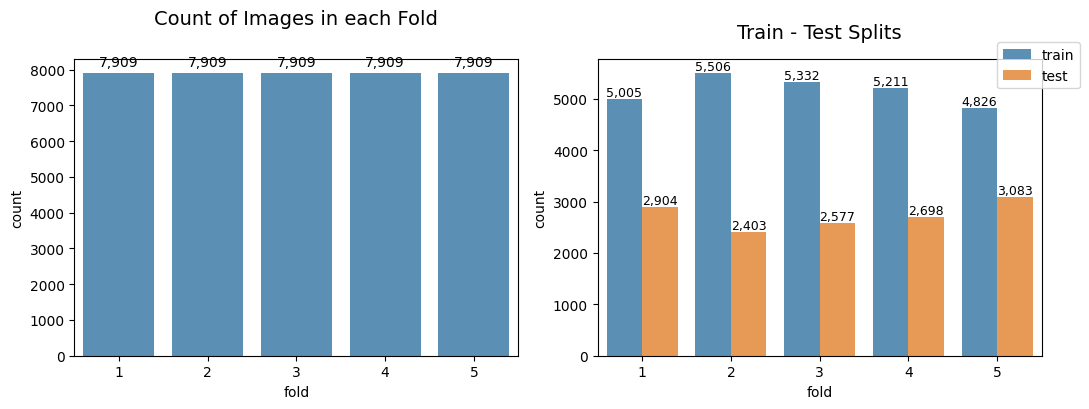

In [9]:
fold_info = pd.read_csv(FOLDS_CSV)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(11, 4.2), tight_layout=True)

sns.countplot(data=fold_info, x="fold", color="C0", ax=ax1, alpha=0.8)
bars = ax1.containers[0]
ax1.bar_label(bars, padding=3,
             labels=[f"{x:,.0f}" for x in bars.datavalues])
ax1.set_title("Count of Images in each Fold", size=14, pad=25)

# Plot train-test split
sns.countplot(data=fold_info, x="fold", hue="grp", palette="tab10",
              ax=ax2, alpha=0.8)
for bars in ax2.containers:
    ax2.bar_label(bars, [f"{x:,.0f}" for x in bars.datavalues], size=9)

ax2.set_title("Train - Test Splits", size=14, pad=15)
ax2.legend(loc=(0.9, 0.9));

Fold’ların toplam görüntü sayısı aynı olsa da train/test oranları farklıdır. Bu nedenle fold bazlı performans farklılıkları veri dağılımından etkilenebilir. Fold 1’de 5005 train ve 2904 test görüntüsü bulunurken, Fold 2’de 5506 train ve 2403 test görüntüsü bulunmaktadır. Fold 5 ise 4826 train ve 3083 test görüntüsü ile en düşük train, en yüksek test sayısına sahip fold’dur.

# Veri Hazırlama

In [10]:
import os
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

OUTPUT_SAVE_DIR = "Split_Dataframes"


os.makedirs(OUTPUT_SAVE_DIR, exist_ok=True)

def create_correct_dataframes(csv_path, imgs_base_dir, save_dir, val_size=0.20, seed=42):
    print(" Folds.csv Üzerinden Sızıntısız Ayrımı\n")


    df = pd.read_csv(csv_path)

    def extract_patient_id(filename):
        basename = filename.split('/')[-1]
        parts = basename.split('-')
        return "-".join(parts[:-2])

    df['patient_id'] = df['filename'].apply(extract_patient_id)
    df['label'] = df['filename'].apply(lambda x: 'malignant' if 'malignant' in x else 'benign')


    df['filepath'] = df['filename'].apply(lambda x: os.path.join(imgs_base_dir, x))


    for fold_num in range(1, 6):
        print(f"  İşleniyor: FOLD {fold_num}")

        # SADECE o fold'un TRAIN verilerini alıyoruz
        # Test verilerine hiç dokunmuyoruz, onlar CSV'de 'grp'=='test' olarak kalıyor
        train_subset = df[(df['fold'] == fold_num) & (df['grp'] == 'train')].copy()

        # 4. GroupShuffleSplit ile Hastaları Parçalamadan Bölme
        gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
        train_idx, val_idx = next(gss.split(train_subset, groups=train_subset['patient_id']))

        train_df = train_subset.iloc[train_idx].reset_index(drop=True)
        val_df = train_subset.iloc[val_idx].reset_index(drop=True)


        leakage = set(train_df['patient_id']).intersection(set(val_df['patient_id']))
        if len(leakage) == 0:
            print("       SIZINTI DURUMU: TEMİZ!")
        else:
            print(f"     DİKKAT SIZINTI VAR! Kesişen hasta: {len(leakage)}")


        train_csv = os.path.join(save_dir, f"fold{fold_num}_train.csv")
        val_csv = os.path.join(save_dir, f"fold{fold_num}_val.csv")

        train_df.to_csv(train_csv, index=False)
        val_df.to_csv(val_csv, index=False)

        print(f"    Kaydedildi: {train_csv} ({len(train_df)} Görüntü)")
        print(f"    Kaydedildi: {val_csv} ({len(val_df)} Görüntü)")
        print("-" * 50)

    print(" Bütün Train ve Val DataFrameleri Başarıyla Oluşturuldu!")


create_correct_dataframes(FOLDS_CSV, IMGS_PATH, OUTPUT_SAVE_DIR)

 Folds.csv Üzerinden Sızıntısız Ayrımı

  İşleniyor: FOLD 1
       SIZINTI DURUMU: TEMİZ!
    Kaydedildi: Split_Dataframes/fold1_train.csv (3912 Görüntü)
    Kaydedildi: Split_Dataframes/fold1_val.csv (1093 Görüntü)
--------------------------------------------------
  İşleniyor: FOLD 2
       SIZINTI DURUMU: TEMİZ!
    Kaydedildi: Split_Dataframes/fold2_train.csv (4404 Görüntü)
    Kaydedildi: Split_Dataframes/fold2_val.csv (1102 Görüntü)
--------------------------------------------------
  İşleniyor: FOLD 3
       SIZINTI DURUMU: TEMİZ!
    Kaydedildi: Split_Dataframes/fold3_train.csv (4305 Görüntü)
    Kaydedildi: Split_Dataframes/fold3_val.csv (1027 Görüntü)
--------------------------------------------------
  İşleniyor: FOLD 4
       SIZINTI DURUMU: TEMİZ!
    Kaydedildi: Split_Dataframes/fold4_train.csv (4136 Görüntü)
    Kaydedildi: Split_Dataframes/fold4_val.csv (1075 Görüntü)
--------------------------------------------------
  İşleniyor: FOLD 5
       SIZINTI DURUMU: TEMİZ!
  

Her fold’un orijinal train verisi kullanılarak hasta bazlı train ve validation setleri oluşturulmuştur. Test setleri bu aşamada kullanılmamış ve modelin nihai değerlendirmesi için ayrı tutulmuştur.

Train-validation ayrımı görüntü bazlı değil, hasta bazlı gerçekleştirildiğinden aynı hastaya ait görüntülerin her iki sette bulunması engellenmiştir.

In [11]:
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import os

# Kaydettiğimiz klasör yolu
SPLIT_DIR = "Split_Dataframes"

def calculate_and_save_class_weights(split_dir):
    print("  Sınıf Ağırlıkları (Class Weights) Hesaplama Süreci Başlıyor...")
    print("-" * 65)

    # 5 Fold için döngü
    for fold_num in range(1, 6):
        train_csv_path = os.path.join(split_dir, f"fold{fold_num}_train.csv")

        if not os.path.exists(train_csv_path):
            print(f"⚠️ Hata: {train_csv_path} bulunamadı.")
            continue

        # CSV'yi yükle
        train_df = pd.read_csv(train_csv_path)

        # Sınıfları ve etiketleri al
        labels = train_df['label'].values
        classes = np.unique(labels)


        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=labels
        )


        class_weights_dict = {0: weights[0], 1: weights[1]}

        print(f"   FOLD {fold_num} İçin Sınıf Ağırlıkları:")
        print(f"   - Benign (İyi Huylu, Sınıf 0)    : {class_weights_dict[0]:.4f}")
        print(f"   - Malignant (Kötü Huylu, Sınıf 1): {class_weights_dict[1]:.4f}")


    print("-" * 65)
    print("   Tüm Fold'lar İçin Sınıf Ağırlıkları Hazır!")

# Çalıştır
calculate_and_save_class_weights(SPLIT_DIR)

  Sınıf Ağırlıkları (Class Weights) Hesaplama Süreci Başlıyor...
-----------------------------------------------------------------
   FOLD 1 İçin Sınıf Ağırlıkları:
   - Benign (İyi Huylu, Sınıf 0)    : 1.7638
   - Malignant (Kötü Huylu, Sınıf 1): 0.6978
   FOLD 2 İçin Sınıf Ağırlıkları:
   - Benign (İyi Huylu, Sınıf 0)    : 1.6263
   - Malignant (Kötü Huylu, Sınıf 1): 0.7220
   FOLD 3 İçin Sınıf Ağırlıkları:
   - Benign (İyi Huylu, Sınıf 0)    : 1.6406
   - Malignant (Kötü Huylu, Sınıf 1): 0.7192
   FOLD 4 İçin Sınıf Ağırlıkları:
   - Benign (İyi Huylu, Sınıf 0)    : 1.7105
   - Malignant (Kötü Huylu, Sınıf 1): 0.7065
   FOLD 5 İçin Sınıf Ağırlıkları:
   - Benign (İyi Huylu, Sınıf 0)    : 1.8403
   - Malignant (Kötü Huylu, Sınıf 1): 0.6865
-----------------------------------------------------------------
   Tüm Fold'lar İçin Sınıf Ağırlıkları Hazır!


Veri setindeki sınıf dengesizliğini azaltmak amacıyla her fold’un train seti için class weight değerleri hesaplanmıştır. Benign sınıfına ait ağırlıkların (1.63–1.84) malignant sınıfına ait ağırlıklardan (0.69–0.72) daha yüksek olması, benign örneklerin eğitim verisinde daha az bulunduğunu göstermektedir

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=360,       # tam tur döndür
    width_shift_range=0.2,    # Yatay kaydırma
    height_shift_range=0.2,   # Dikey kaydırma
    shear_range=0.2,          # Kesme (doku deformasyonu simülasyonu)
    zoom_range=0.3,           # RANDOM SCALE: 40X-400X farkını bu "zoom" ile simüle ediyoruz
    horizontal_flip=True,     # Yatay çevir
    vertical_flip=True,       # Dikey çevir
    fill_mode='reflect'
)

# VALIDATION için Augmentation yapmadım,yalnızca ölçekleme
val_datagen = ImageDataGenerator(
    rescale=1./255
)

Bu aşamada modelin genelleme kabiliyetini artırmak ve overfitting riskini azaltmak amacıyla eğitim verilerine veri artırma uygulanmıştır. Validation setine ise augmentation uygulanmamış, yalnızca model girişine uygun ön işleme yapılmıştır.

# DenseNet121 Model Eğitimi

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
SPLIT_DIR     = "Split_Dataframes"
from google.colab import drive
drive.mount('/content/drive')

MODELS_DIR = "/content/drive/MyDrive/breakhis_models"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

IMG_SIZE  = (224, 224)
BATCH     = 32
SEED      = 42
print(" İmportlar ve sabitler hazır.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 İmportlar ve sabitler hazır.


Daha önce oluşturulan train-validation CSV dosyalarının okunacağı klasör ve eğitilen modellerin kaydedileceği Google Drive dizini tanımlanmıştır.

In [ ]:
IMGS_PATH = "/content/breakhis/BreaKHis_v1"



import pandas as pd, os

SPLIT_DIR = "Split_Dataframes"



for fold_num in range(1, 6):

    for split in ['train', 'val']:

        path = os.path.join(SPLIT_DIR, f"fold{fold_num}_{split}.csv")

        df = pd.read_csv(path)

        df['filepath'] = df['filename'].apply(

            lambda x: os.path.join(IMGS_PATH, x)

        )

        df.to_csv(path, index=False)

In [ ]:
def build_densenet_model(input_shape=(224, 224, 3)):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x) # 0.5 ile overfitting'i daha iyi baskılarız
    # Binary sınıflandırma için tek çıkışlı sigmoid!
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model, base_model


def train_with_fine_tuning(model, base_model, train_gen, val_gen,
                           class_weights, fold_num, models_dir):
    """
    Phase-1: Sadece head katmanlarını eğit (10 epoch, lr=1e-3)
    Phase-2: Tüm ağı aç, çok küçük lr ile fine-tune et (max 30 epoch)
    Her iki fazda da sınıf ağırlıkları ve EarlyStopping kullanılır.
    En iyi model diske kaydedilir.
    """
    save_path = os.path.join(models_dir, f"densenet_fold{fold_num}.keras")

    # ── PHASE 1: Feature Extraction ────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  FOLD {fold_num} │ PHASE 1: Feature Extraction (lr=1e-3)")
    print(f"{'='*55}")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    )

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        class_weight=class_weights,
        verbose=1
    )

    # ── PHASE 2: Fine-Tuning ───────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  FOLD {fold_num} │ PHASE 2: Fine-Tuning (lr=1e-5)")
    print(f"{'='*55}")
    base_model.trainable = True

    model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            save_path, monitor='val_loss', save_best_only=True, verbose=1
        )
    ]
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    print(f"\n💾 En iyi model kaydedildi: {save_path}")
    return history, save_path


print(" Model fonksiyonları tanımlandı.")

 Model fonksiyonları tanımlandı.


Bu aşamada DenseNet121 tabanlı transfer learning modeli oluşturulmuştur. DenseNet121 modeli ImageNet ağırlıklarıyla yüklenmiş ve include_top=False kullanılarak modelin orijinal sınıflandırma katmanı çıkarılmıştır. Bunun yerine histopatolojik görüntülerin benign ve malignant olarak sınıflandırılabilmesi için GlobalAveragePooling2D, Dropout ve sigmoid aktivasyonlu tek nöronlu çıkış katmanı eklenmiştir.

Model eğitimi iki aşamalı olarak gerçekleştirilmiştir. İlk aşamada DenseNet121 tabanı dondurulmuş ve yalnızca yeni eklenen sınıflandırıcı katman eğitilmiştir. Bu aşamada amaç, önceden öğrenilmiş genel görsel özellikleri bozmadan modelin yeni veri setine uyum sağlamasını sağlamaktır. İkinci aşamada ise base_model.trainable = True yapılarak DenseNet121 tabanının tamamı eğitime açılmış ve düşük öğrenme oranı ile fine-tuning uygulanmıştır. Bu işlem, modelin önceden öğrendiği genel özellikleri koruyarak BreaKHis veri setine daha iyi adapte olmasını amaçlamaktadır.

Fine-tuning aşamasında öğrenme oranı 1e-5 olarak seçilmiştir. Bunun nedeni, önceden eğitilmiş DenseNet ağırlıklarının ani ve büyük güncellemelerle bozulmasını engellemektir. Küçük learning rate sayesinde model daha kontrollü şekilde güncellenmiş ve medikal görüntü verisine uyarlanmıştır.

Modelde Dropout(0.5) kullanılmıştır. Dropout, eğitim sırasında nöronların bir kısmını rastgele devre dışı bırakarak modelin belirli özelliklere aşırı bağımlı hale gelmesini engeller. Bu projede veri seti hasta bazlı sınırlı olduğundan ve medikal görüntülerde overfitting riski bulunduğundan, 0.5 dropout oranı modelin genelleme kabiliyetini artırmak için tercih edilmiştir.

Her iki eğitim aşamasında da class weight kullanılmıştır. Böylece veri setindeki benign ve malignant sınıf dengesizliğinin eğitim sürecine etkisi azaltılmış, azınlık sınıf olan benign örneklerin loss üzerindeki etkisi artırılmıştır.



############################################################
#  FOLD 1 / 5 BAŞLIYOR
############################################################
⚖️  Class Weights → benign: 1.764, malignant: 0.698
Found 3912 validated image filenames belonging to 2 classes.
Found 1093 validated image filenames belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

  FOLD 1 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.6130 - auc: 0.6543 - loss: 0.6723 - precision: 0.8042 - recall: 0.6079 - val_accuracy: 0.6267 - val_auc: 0.6478 - val_loss: 0.6766 - val_precision: 0.7795 - val_recall: 0.6151
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 98s 797ms/step - accuracy: 0.7211 - auc: 0.7949 - loss: 0.5517 - precision: 0.8658 - recall: 0.7228 - val_accuracy: 0.6780 - val_auc: 0.6670 - val_loss: 0.6540 - val_precision: 0.7981 - val_recall: 0.6932
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 98s 798ms/step - accuracy: 0.7738 - auc: 0.8415 - l

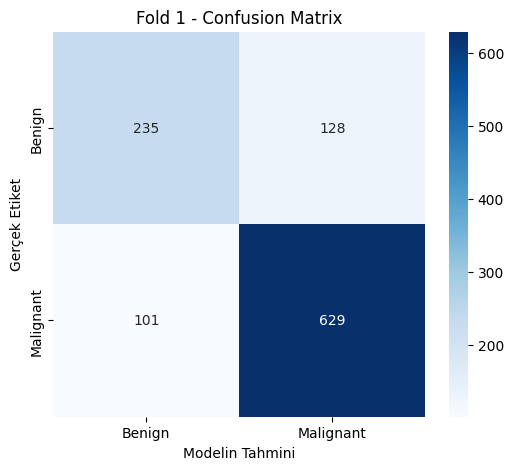


############################################################
#  FOLD 2 / 5 BAŞLIYOR
############################################################
⚖️  Class Weights → benign: 1.626, malignant: 0.722
Found 4404 validated image filenames belonging to 2 classes.
Found 1102 validated image filenames belonging to 2 classes.

  FOLD 2 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.6094 - auc: 0.6386 - loss: 0.6838 - precision: 0.7697 - recall: 0.6223 - val_accuracy: 0.5862 - val_auc: 0.7167 - val_loss: 0.6820 - val_precision: 0.8081 - val_recall: 0.4571
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 109s 788ms/step - accuracy: 0.7091 - auc: 0.7862 - loss: 0.5620 - precision: 0.8506 - recall: 0.7036 - val_accuracy: 0.5962 - val_auc: 0.7687 - val_loss: 0.6651 - val_precision: 0.8164 - val_recall: 0.4700
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 109s 789ms/step - accuracy: 0.7434 - auc: 0.8254 - loss: 0.5187 - precision: 0.8692 - recall: 0.7410 

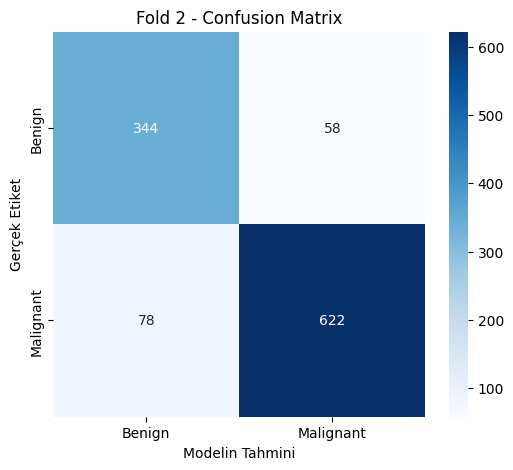


############################################################
#  FOLD 3 / 5 BAŞLIYOR
############################################################
⚖️  Class Weights → benign: 1.641, malignant: 0.719
Found 4305 validated image filenames belonging to 2 classes.
Found 1027 validated image filenames belonging to 2 classes.

  FOLD 3 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.5686 - auc: 0.5984 - loss: 0.7136 - precision: 0.7565 - recall: 0.5596 - val_accuracy: 0.6397 - val_auc: 0.7332 - val_loss: 0.6586 - val_precision: 0.8486 - val_recall: 0.5102
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 107s 790ms/step - accuracy: 0.6794 - auc: 0.7312 - loss: 0.6088 - precision: 0.8164 - recall: 0.6953 - val_accuracy: 0.6563 - val_auc: 0.7720 - val_loss: 0.6413 - val_precision: 0.8797 - val_recall: 0.5165
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 106s 787ms/step - accuracy: 0.7185 - auc: 0.7772 - loss: 0.5704 - precision: 0.8521 - recall: 0.7200 

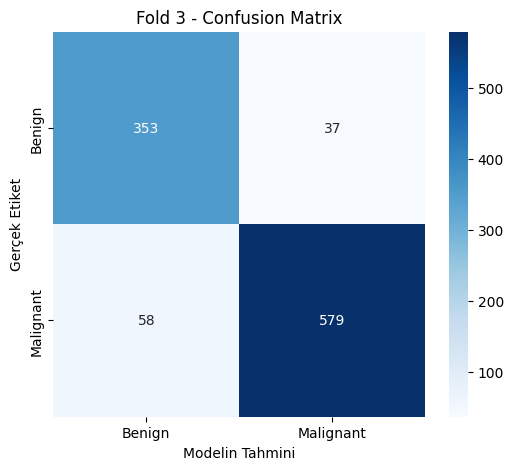


############################################################
#  FOLD 4 / 5 BAŞLIYOR
############################################################
⚖️  Class Weights → benign: 1.711, malignant: 0.707
Found 4136 validated image filenames belonging to 2 classes.
Found 1075 validated image filenames belonging to 2 classes.

  FOLD 4 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.6069 - auc: 0.6501 - loss: 0.6667 - precision: 0.7900 - recall: 0.6054 - val_accuracy: 0.6726 - val_auc: 0.7592 - val_loss: 0.6396 - val_precision: 0.8672 - val_recall: 0.6184
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 103s 793ms/step - accuracy: 0.7171 - auc: 0.7782 - loss: 0.5713 - precision: 0.8605 - recall: 0.7164 - val_accuracy: 0.7805 - val_auc: 0.8334 - val_loss: 0.5331 - val_precision: 0.8759 - val_recall: 0.7930
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 103s 794ms/step - accuracy: 0.7350 - auc: 0.8064 - loss: 0.5393 - precision: 0.8626 - recall: 0.7441 

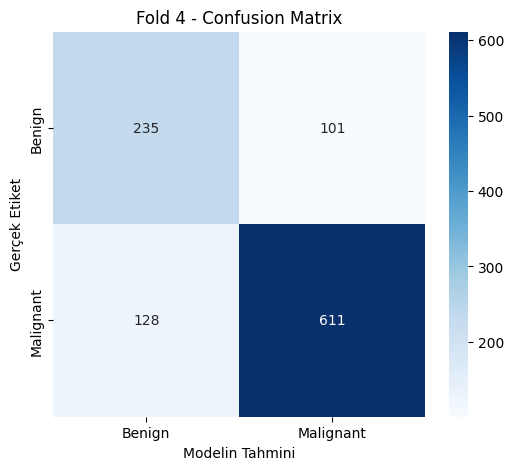


############################################################
#  FOLD 5 / 5 BAŞLIYOR
############################################################
⚖️  Class Weights → benign: 1.840, malignant: 0.687
Found 3894 validated image filenames belonging to 2 classes.
Found 932 validated image filenames belonging to 2 classes.

  FOLD 5 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.6325 - auc: 0.6596 - loss: 0.6672 - precision: 0.8124 - recall: 0.6442 - val_accuracy: 0.5418 - val_auc: 0.6883 - val_loss: 0.7386 - val_precision: 0.7325 - val_recall: 0.4155
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 96s 784ms/step - accuracy: 0.7165 - auc: 0.7854 - loss: 0.5606 - precision: 0.8679 - recall: 0.7204 - val_accuracy: 0.6052 - val_auc: 0.7048 - val_loss: 0.6720 - val_precision: 0.7335 - val_recall: 0.5741
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 95s 782ms/step - accuracy: 0.7496 - auc: 0.8256 - loss: 0.5165 - precision: 0.8850 - recall: 0.7542 - v

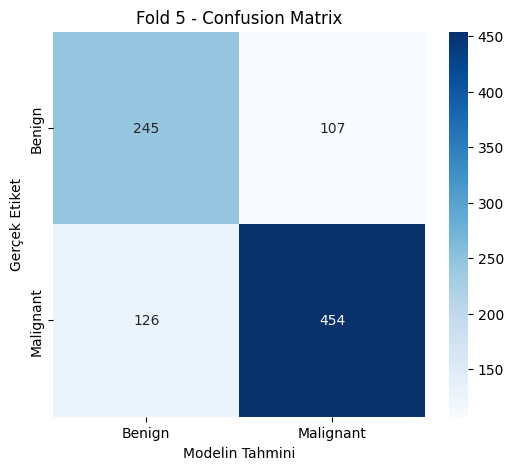


  5-FOLD CROSS VALIDATION SONUÇLARI (DenseNet121)
  Fold 1  →  Val AUC: 0.8215
  Fold 2  →  Val AUC: 0.9436
  Fold 3  →  Val AUC: 0.9703
  Fold 4  →  Val AUC: 0.8583
  Fold 5  →  Val AUC: 0.8161
-------------------------------------------------------
  Ortalama AUC : 0.8820  ±  0.0635


In [ ]:
fold_results = []

for fold_num in range(1, 6):
    print(f"\n{'#'*60}")
    print(f"#  FOLD {fold_num} / 5 BAŞLIYOR")
    print(f"{'#'*60}")


    train_df = pd.read_csv(os.path.join(SPLIT_DIR, f"fold{fold_num}_train.csv"))
    val_df   = pd.read_csv(os.path.join(SPLIT_DIR, f"fold{fold_num}_val.csv"))


    if not train_df['filepath'].iloc[0].startswith('/'):
        train_df['filepath'] = train_df['filename'].apply(
            lambda x: os.path.join(IMGS_PATH, x)
        )
        val_df['filepath'] = val_df['filename'].apply(
            lambda x: os.path.join(IMGS_PATH, x)
        )


    labels = train_df['label'].values
    classes = np.unique(labels)  # ['benign', 'malignant']
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    # flow_from_dataframe alfabetik sıralar: benign=0, malignant=1
    class_weights = {0: weights[0], 1: weights[1]}
    print(f"⚖️  Class Weights → benign: {class_weights[0]:.3f}, malignant: {class_weights[1]:.3f}")


    train_gen = train_datagen.flow_from_dataframe(
        train_df,
        x_col='filepath',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode='binary',
        shuffle=True,
        seed=SEED
    )
    val_gen = val_datagen.flow_from_dataframe(
        val_df,
        x_col='filepath',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode='binary',
        shuffle=False
    )


    tf.keras.backend.clear_session()  # Her fold'da temiz başladım
    model, base_model = build_densenet_model()

    history, saved_path = train_with_fine_tuning(
        model, base_model, train_gen, val_gen,
        class_weights, fold_num, MODELS_DIR
    )


    val_gen.reset()
    y_pred_proba = model.predict(val_gen, verbose=0)
    y_true = val_gen.classes

    val_auc = roc_auc_score(y_true, y_pred_proba)
    print(f"\n📊 FOLD {fold_num} Validation ROC-AUC: {val_auc:.4f}")

    fold_results.append({
        'fold': fold_num,
        'val_auc': val_auc,
        'model_path': saved_path
    })

    y_pred_classes = (y_pred_proba > 0.5).astype("int32")


    cm = confusion_matrix(y_true, y_pred_classes)


    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Modelin Tahmini')
    plt.title(f'Fold {fold_num} - Confusion Matrix')
    plt.show()

# ─── Özet Tablo ───────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  5-FOLD CROSS VALIDATION SONUÇLARI (DenseNet121)")
print("="*55)
aucs = [r['val_auc'] for r in fold_results]
for r in fold_results:
    print(f"  Fold {r['fold']}  →  Val AUC: {r['val_auc']:.4f}")
print("-"*55)
print(f"  Ortalama AUC : {np.mean(aucs):.4f}  ±  {np.std(aucs):.4f}")
print("="*55)

DenseNet121 modeli 5-fold cross-validation yöntemiyle eğitilmiş ve her fold için validation ROC-AUC değeri hesaplanmıştır. Elde edilen sonuçlara göre modelin ortalama validation AUC değeri **0.8820 ± 0.0635** olarak bulunmuştur. Bu sonuç, modelin benign ve malignant sınıfları genel olarak ayırt edebildiğini göstermektedir.

Fold bazlı sonuçlar incelendiğinde en yüksek performans Fold 3’te **0.9703 AUC**, en düşük performans ise Fold 5’te **0.8161 AUC** olarak elde edilmiştir. Fold’lar arasındaki bu fark, hasta bazlı ayrım nedeniyle her fold’da farklı hasta gruplarının bulunmasından ve train-validation dağılımlarının birebir aynı olmamasından kaynaklanır.

# DenseNet121 Model Analizi

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

def get_val_generator(fold_num):
    val_df = pd.read_csv(os.path.join(SPLIT_DIR, f"fold{fold_num}_val.csv"))

    # filepath yoksa veya bozuksa yeniden oluştur
    if "filepath" not in val_df.columns or not os.path.exists(val_df["filepath"].iloc[0]):
        val_df["filepath"] = val_df["filename"].apply(
            lambda x: os.path.join(IMGS_PATH, x)
        )

    val_gen = val_datagen.flow_from_dataframe(
        val_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode="binary",
        classes=["benign", "malignant"],
        shuffle=False
    )

    return val_df, val_gen


def evaluate_all_folds():
    results = []

    for fold_num in range(1, 6):
        print(f"\n{'='*60}")
        print(f"FOLD {fold_num} DETAYLI VALIDATION ANALİZİ")
        print(f"{'='*60}")

        val_df, val_gen = get_val_generator(fold_num)

        model_path = os.path.join(MODELS_DIR, f"densenet_fold{fold_num}.keras")
        model = load_model(model_path)

        val_gen.reset()
        y_true = val_gen.classes
        y_prob = model.predict(val_gen, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        fold_result = {
            "fold": fold_num,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision_malignant": precision_score(y_true, y_pred, zero_division=0),
            "recall_malignant": recall_score(y_true, y_pred, zero_division=0),
            "specificity_benign": specificity,
            "f1_malignant": f1_score(y_true, y_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "roc_auc": roc_auc_score(y_true, y_prob),
            "pr_auc": average_precision_score(y_true, y_prob),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        }

        results.append(fold_result)

        print(classification_report(
            y_true,
            y_pred,
            target_names=["Benign", "Malignant"],
            zero_division=0
        ))

    results_df = pd.DataFrame(results)

    print("\n5-FOLD DETAYLI SONUÇ TABLOSU")
    display(results_df)

    print("\nORTALAMA ± STANDART SAPMA")
    summary_df = results_df[
        [
            "accuracy",
            "precision_malignant",
            "recall_malignant",
            "specificity_benign",
            "f1_malignant",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc"
        ]
    ].agg(["mean", "std"])

    display(summary_df)

    return results_df, summary_df


validation_results_df, validation_summary_df = evaluate_all_folds()


FOLD 1 DETAYLI VALIDATION ANALİZİ
Found 1093 validated image filenames belonging to 2 classes.
              precision    recall  f1-score   support

      Benign       0.70      0.65      0.67       363
   Malignant       0.83      0.86      0.85       730

    accuracy                           0.79      1093
   macro avg       0.77      0.75      0.76      1093
weighted avg       0.79      0.79      0.79      1093


FOLD 2 DETAYLI VALIDATION ANALİZİ
Found 1102 validated image filenames belonging to 2 classes.
              precision    recall  f1-score   support

      Benign       0.82      0.86      0.83       402
   Malignant       0.91      0.89      0.90       700

    accuracy                           0.88      1102
   macro avg       0.86      0.87      0.87      1102
weighted avg       0.88      0.88      0.88      1102


FOLD 3 DETAYLI VALIDATION ANALİZİ
Found 1027 validated image filenames belonging to 2 classes.
              precision    recall  f1-score   support

   

,fold,accuracy,precision_malignant,recall_malignant,specificity_benign,f1_malignant,balanced_accuracy,roc_auc,pr_auc,TN,FP,FN,TP
0,1,0.790485,0.830911,0.861644,0.647383,0.845999,0.754513,0.821506,0.887587,235,128,101,629
1,2,0.876588,0.914706,0.888571,0.855721,0.901449,0.872146,0.943646,0.968622,344,58,78,622
2,3,0.907498,0.939935,0.908948,0.905128,0.924182,0.907038,0.970253,0.981616,353,37,58,579
3,4,0.786977,0.858146,0.826793,0.699405,0.842178,0.763099,0.858335,0.931548,235,101,128,611
4,5,0.750000,0.809269,0.782759,0.696023,0.795793,0.739391,0.816066,0.862169,245,107,126,454



ORTALAMA ± STANDART SAPMA


,accuracy,precision_malignant,recall_malignant,specificity_benign,f1_malignant,balanced_accuracy,roc_auc,pr_auc
mean,0.822309,0.870594,0.853743,0.760732,0.861920,0.807238,0.881961,0.926309
std,0.066508,0.055327,0.050220,0.112550,0.051125,0.076656,0.070985,0.051210


DenseNet121 modeli 5-fold validation sonucunda ortalama 0.8820 ROC-AUC ve 0.9263 PR-AUC elde etmiştir. Bu sonuçlar modelin benign ve malignant sınıfları ayırmada genel olarak başarılı olduğunu göstermektedir. Malignant sınıfı için ortalama recall değeri 0.8537, F1-score değeri ise 0.8619 olarak bulunmuştur. Bu durum modelin kötü huylu örnekleri büyük oranda doğru yakalayabildiğini göstermektedir.

Bununla birlikte benign specificity ortalamasının 0.7607 olması, modelin bazı benign örnekleri malignant olarak sınıflandırma eğiliminde olduğunu göstermektedir. Fold bazlı sonuçlar incelendiğinde en yüksek performans Fold 3’te, en düşük performans ise Fold 5’te elde edilmiştir. Fold’lar arasındaki bu değişkenlik, hasta bazlı ayrım nedeniyle validation setlerinde farklı hasta gruplarının bulunmasıyla ilişkilendirilebilir.

Found 1093 validated image filenames belonging to 2 classes.
Found 1102 validated image filenames belonging to 2 classes.
Found 1027 validated image filenames belonging to 2 classes.
Found 1075 validated image filenames belonging to 2 classes.
Found 932 validated image filenames belonging to 2 classes.


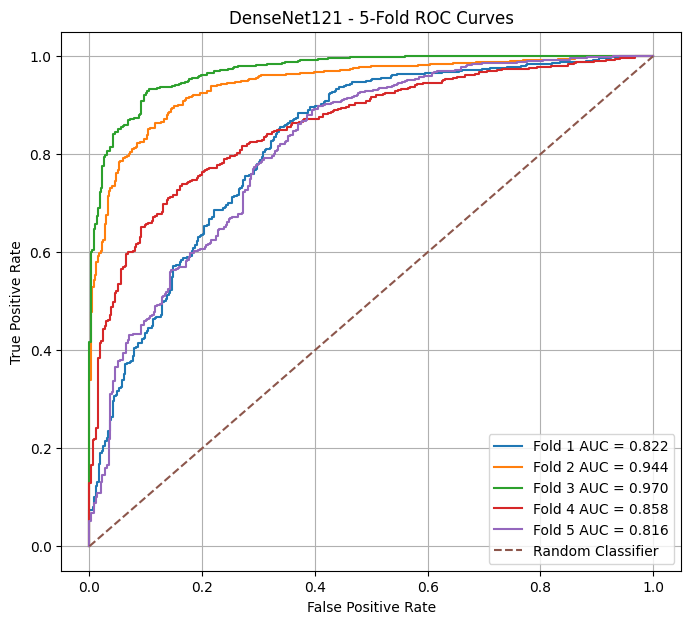

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves_all_folds():
    plt.figure(figsize=(8, 7))

    for fold_num in range(1, 6):
        val_df, val_gen = get_val_generator(fold_num)

        model_path = os.path.join(MODELS_DIR, f"densenet_fold{fold_num}.keras")
        model = load_model(model_path)

        val_gen.reset()
        y_true = val_gen.classes
        y_prob = model.predict(val_gen, verbose=0).ravel()

        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Fold {fold_num} AUC = {roc_auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("DenseNet121 - 5-Fold ROC Curves")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc_curves_all_folds()

ROC eğrileri incelendiğinde, DenseNet121 modelinin tüm fold’larda rastgele sınıflandırıcı çizgisinin üzerinde performans gösterdiği görülmektedir. Bu durum, modelin benign ve malignant sınıflar arasında anlamlı bir ayrım yapabildiğini göstermektedir. En yüksek AUC değeri Fold 3’te 0.970, ardından Fold 2’de 0.944 olarak elde edilmiştir. Fold 1 ve Fold 5 ise sırasıyla 0.822 ve 0.816 AUC değerleriyle daha düşük performans göstermiştir.

Fold’lar arasındaki bu performans farkı, hasta bazlı veri ayrımı nedeniyle validation setlerinde farklı hasta gruplarının bulunmasından kaynaklanabilir. Genel olarak ROC analizleri, modelin sınıfları ayırma kapasitesinin güçlü olduğunu; ancak bazı fold’larda hasta dağılımına bağlı olarak performansın düştüğünü göstermektedir.

Found 1093 validated image filenames belonging to 2 classes.
Found 1102 validated image filenames belonging to 2 classes.
Found 1027 validated image filenames belonging to 2 classes.
Found 1075 validated image filenames belonging to 2 classes.
Found 932 validated image filenames belonging to 2 classes.


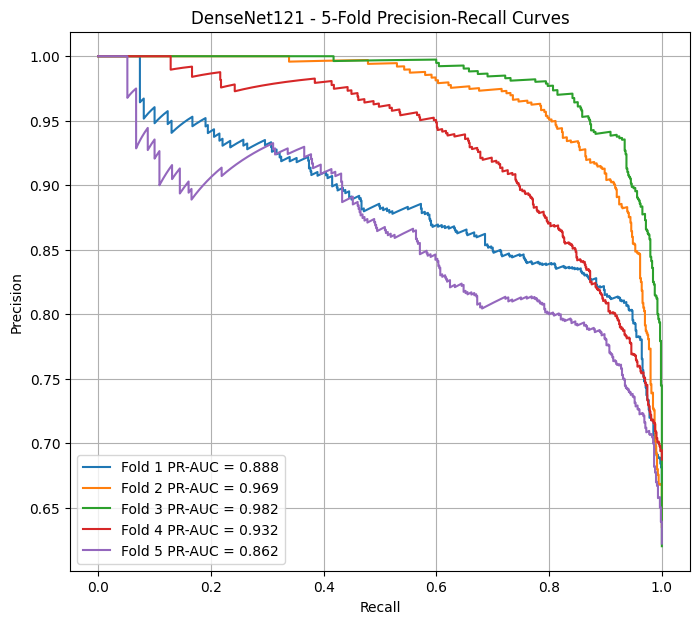

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curves_all_folds():
    plt.figure(figsize=(8, 7))

    for fold_num in range(1, 6):
        val_df, val_gen = get_val_generator(fold_num)

        model_path = os.path.join(MODELS_DIR, f"densenet_fold{fold_num}.keras")
        model = load_model(model_path)

        val_gen.reset()
        y_true = val_gen.classes
        y_prob = model.predict(val_gen, verbose=0).ravel()

        precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)

        plt.plot(recall, precision, label=f"Fold {fold_num} PR-AUC = {pr_auc:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("DenseNet121 - 5-Fold Precision-Recall Curves")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_pr_curves_all_folds()

Precision-Recall eğrileri incelendiğinde DenseNet121 modelinin malignant sınıfını ayırt etmede genel olarak başarılı olduğu görülmektedir. Ortalama PR-AUC değeri 0.9263 olarak elde edilmiştir. En yüksek PR-AUC değeri Fold 3’te 0.982, en düşük değer ise Fold 5’te 0.862 olarak bulunmuştur. Bu sonuçlar ROC-AUC ve confusion matrix analizleriyle tutarlıdır.

Fold 2 ve Fold 3’te precision değerinin yüksek recall seviyelerinde bile güçlü kalması, modelin malignant örnekleri yüksek doğrulukla yakalayabildiğini göstermektedir. Buna karşılık Fold 1 ve Fold 5’te precision daha erken düşmektedir. Bu durum, ilgili fold’larda bazı benign örneklerin malignant olarak sınıflandırıldığını ve false positive hatalarının arttığını göstermektedir.

Genel olarak PR curve analizi, modelin malignant sınıfını yakalama kapasitesinin güçlü olduğunu; ancak bazı fold’larda benign-malignant ayrımının daha zorlaştığını ortaya koymaktadır.

# EfficientNetV2S Model Eğitimi

DenseNet121 modelinin validation sonuçları incelendiğinde modelin genel olarak başarılı bir performans gösterdiği, ancak benign sınıfında bazı örnekleri malignant olarak sınıflandırma eğilimi bulunduğu görülmüştür. Bu nedenle model performansını karşılaştırmak ve benign sınıfındaki hataları azaltıp azaltamayacağını gözlemlemek amacıyla ikinci bir transfer learning modeli olarak EfficientNetV2S eğitilmiştir.

Karşılaştırmanın adil olabilmesi için EfficientNetV2S modeli, DenseNet121 ile aynı hasta bazlı train-validation fold yapısı kullanılarak eğitilmiştir. Eğitim sürecinde kullanılan augmentation stratejisi, class weight değerleri, batch size, görüntü boyutu ve değerlendirme metrikleri aynı tutulmuştur. Böylece iki model arasındaki performans farkının veri bölünmesi veya eğitim ayarlarındaki farklılıklardan değil, model mimarisinden kaynaklanması hedeflenmiştir.

Final test değerlendirmesinde de EfficientNetV2S modeli, DenseNet121 ile aynı test fold’ları üzerinde değerlendirilecektir. Bu yaklaşım, iki modelin aynı test örnekleri üzerindeki tahmin olasılıklarının karşılaştırılmasını sağlayacak ve ROC-AUC farkının istatistiksel anlamlılığını değerlendirmek için DeLong testinin adil şekilde uygulanmasına imkân verecektir.


In [13]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve, auc
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from google.colab import drive

drive.mount('/content/drive')

# ── Yollar ────────────────────────────────────────────────────────────────
BASE_PATH  = '/content/breakhis'
IMGS_PATH  = f'{BASE_PATH}/BreaKHis_v1/BreaKHis_v1'
FOLDS_CSV  = f'{BASE_PATH}/Folds.csv'
SPLIT_DIR  = 'Split_Dataframes'   # DenseNet ile aynı CSV'ler kullanılır
MODELS_DIR = '/content/drive/MyDrive/breakhis_models_efficientnet'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Sabitler ──────────────────────────────────────────────────────────────
IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

print('✅ İmportlar ve sabitler hazır.')
print(f'TF sürümü: {tf.__version__}')

Mounted at /content/drive
✅ İmportlar ve sabitler hazır.
TF sürümü: 2.20.0


In [14]:
IMGS_PATH = "/content/breakhis/BreaKHis_v1"



import pandas as pd, os

SPLIT_DIR = "Split_Dataframes"



for fold_num in range(1, 6):

    for split in ['train', 'val']:

        path = os.path.join(SPLIT_DIR, f"fold{fold_num}_{split}.csv")

        df = pd.read_csv(path)

        df['filepath'] = df['filename'].apply(

            lambda x: os.path.join(IMGS_PATH, x)

        )

        df.to_csv(path, index=False)

In [15]:
def build_efficientnet_model(input_shape=(224, 224, 3)):
    base_model = EfficientNetV2S(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # Phase 1'de dondur

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model, base_model


def train_with_fine_tuning(model, base_model, train_gen, val_gen,
                           class_weights, fold_num, models_dir):
    save_path = os.path.join(models_dir, f'efficientnet_fold{fold_num}.keras')

    # ── PHASE 1: Feature Extraction ───────────────────────────
    print(f"\n{'='*55}")
    print(f'  FOLD {fold_num} │ PHASE 1: Feature Extraction (lr=1e-3)')
    print(f"{'='*55}")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        class_weight=class_weights,
        verbose=1
    )

    # ── PHASE 2: Fine-Tuning ──────────────────────────────────
    print(f"\n{'='*55}")
    print(f'  FOLD {fold_num} │ PHASE 2: Fine-Tuning (lr=1e-5)')
    print(f"{'='*55}")
    base_model.trainable = True
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            save_path, monitor='val_loss',
            save_best_only=True, verbose=1
        )
    ]
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    print(f'\n💾 En iyi model kaydedildi: {save_path}')
    return history, save_path


print('✅ EfficientNetV2S model fonksiyonları tanımlandı.')

✅ EfficientNetV2S model fonksiyonları tanımlandı.



############################################################
#  FOLD 1 / 5 BAŞLIYOR
############################################################
  Class Weights → benign: 1.764, malignant: 0.698
Found 3912 validated image filenames belonging to 2 classes.
Found 1093 validated image filenames belonging to 2 classes.
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

  FOLD 1 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.4839 - auc: 0.5496 - loss: 0.6888 - precision: 0.7519 - recall: 0.4174 - val_accuracy: 0.5425 - val_auc: 0.6093 - val_loss: 0.6833 - val_precision: 0.7328 - val_recall: 0.4959
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 98s 799ms/step - accuracy: 0.5225 - auc: 0.5736 - loss: 0.6838 - precision: 0.7704 - recall: 0.4752 - val_accuracy: 0.5242 - val_auc: 0.6669 - val_loss: 0.6869 - val_precision: 0.7853 - val_recall: 0.3959
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 98s 799ms/step - accuracy: 0.5440 - auc: 0.5975 - los

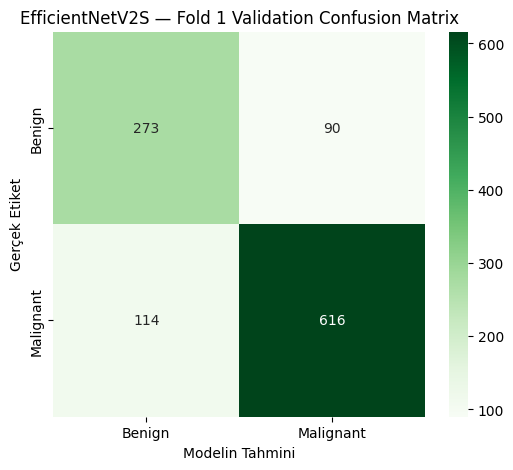


############################################################
#  FOLD 2 / 5 BAŞLIYOR
############################################################
  Class Weights → benign: 1.626, malignant: 0.722
Found 4404 validated image filenames belonging to 2 classes.
Found 1102 validated image filenames belonging to 2 classes.

  FOLD 2 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.5554 - auc: 0.5840 - loss: 0.6827 - precision: 0.7448 - recall: 0.5446 - val_accuracy: 0.4083 - val_auc: 0.3514 - val_loss: 0.7417 - val_precision: 0.5429 - val_recall: 0.4343
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 109s 788ms/step - accuracy: 0.5429 - auc: 0.5797 - loss: 0.6829 - precision: 0.7511 - recall: 0.5085 - val_accuracy: 0.3984 - val_auc: 0.3848 - val_loss: 0.7380 - val_precision: 0.5452 - val_recall: 0.3186
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 108s 786ms/step - accuracy: 0.5543 - auc: 0.5971 - loss: 0.6778 - precision: 0.7645 - recall: 0.5151 - 

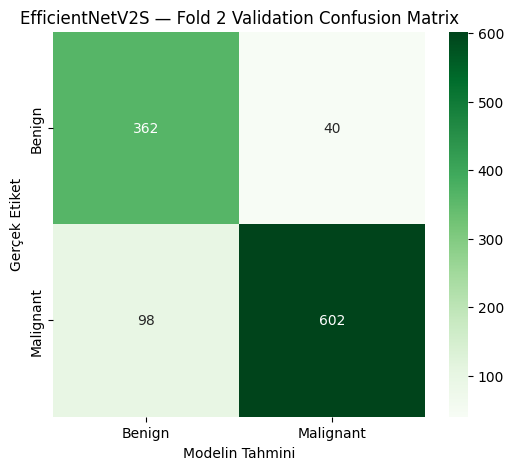


############################################################
#  FOLD 3 / 5 BAŞLIYOR
############################################################
  Class Weights → benign: 1.641, malignant: 0.719
Found 4305 validated image filenames belonging to 2 classes.
Found 1027 validated image filenames belonging to 2 classes.

  FOLD 3 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.5022 - auc: 0.5256 - loss: 0.6948 - precision: 0.7142 - recall: 0.4734 - val_accuracy: 0.6056 - val_auc: 0.5392 - val_loss: 0.6753 - val_precision: 0.6436 - val_recall: 0.8163
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 107s 789ms/step - accuracy: 0.5610 - auc: 0.5411 - loss: 0.6923 - precision: 0.7153 - recall: 0.6121 - val_accuracy: 0.4343 - val_auc: 0.5166 - val_loss: 0.7304 - val_precision: 0.5886 - val_recall: 0.2920
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 106s 787ms/step - accuracy: 0.5689 - auc: 0.5598 - loss: 0.6891 - precision: 0.7316 - recall: 0.6001 - 

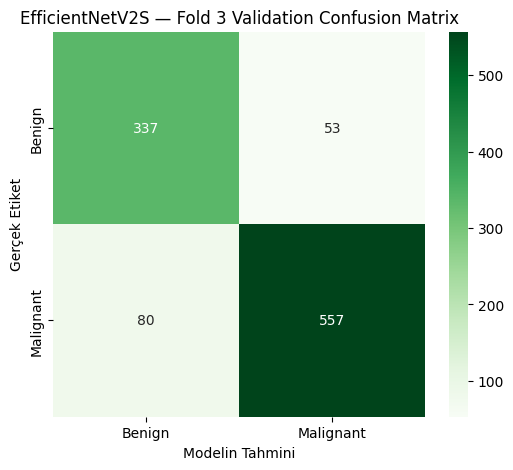


############################################################
#  FOLD 4 / 5 BAŞLIYOR
############################################################
  Class Weights → benign: 1.711, malignant: 0.707
Found 4136 validated image filenames belonging to 2 classes.
Found 1075 validated image filenames belonging to 2 classes.

  FOLD 4 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.5452 - auc: 0.5541 - loss: 0.6884 - precision: 0.7395 - recall: 0.5518 - val_accuracy: 0.4205 - val_auc: 0.4988 - val_loss: 0.7175 - val_precision: 0.6559 - val_recall: 0.3302
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 103s 792ms/step - accuracy: 0.5817 - auc: 0.5578 - loss: 0.6879 - precision: 0.7380 - recall: 0.6341 - val_accuracy: 0.3767 - val_auc: 0.5060 - val_loss: 0.7632 - val_precision: 0.6507 - val_recall: 0.2016
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 103s 792ms/step - accuracy: 0.5892 - auc: 0.5881 - loss: 0.6804 - precision: 0.7516 - recall: 0.6266 - 

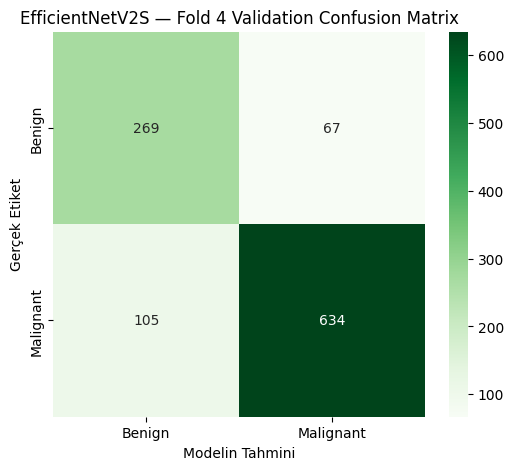


############################################################
#  FOLD 5 / 5 BAŞLIYOR
############################################################
  Class Weights → benign: 1.840, malignant: 0.687
Found 3894 validated image filenames belonging to 2 classes.
Found 932 validated image filenames belonging to 2 classes.

  FOLD 5 │ PHASE 1: Feature Extraction (lr=1e-3)
Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.5218 - auc: 0.5372 - loss: 0.6917 - precision: 0.7442 - recall: 0.5233 - val_accuracy: 0.4217 - val_auc: 0.5260 - val_loss: 0.7142 - val_precision: 0.6145 - val_recall: 0.1897
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 96s 783ms/step - accuracy: 0.5069 - auc: 0.5823 - loss: 0.6809 - precision: 0.7800 - recall: 0.4499 - val_accuracy: 0.4474 - val_auc: 0.6533 - val_loss: 0.6947 - val_precision: 0.6836 - val_recall: 0.2086
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 96s 785ms/step - accuracy: 0.5393 - auc: 0.6049 - loss: 0.6726 - precision: 0.7964 - recall: 0.4937 - val

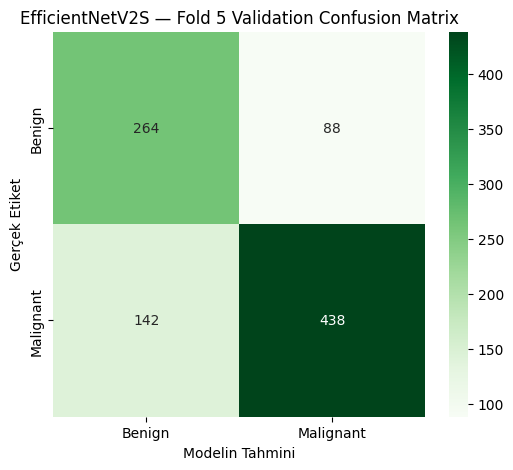


  5-FOLD CROSS VALIDATION SONUÇLARI (EfficientNetV2S)
  Fold 1  →  Val AUC: 0.8934
  Fold 2  →  Val AUC: 0.9403
  Fold 3  →  Val AUC: 0.9444
  Fold 4  →  Val AUC: 0.9124
  Fold 5  →  Val AUC: 0.8361
-------------------------------------------------------
  Ortalama AUC : 0.9053  ±  0.0393


In [16]:
fold_results = []

for fold_num in range(1, 6):
    print(f"\n{'#'*60}")
    print(f'#  FOLD {fold_num} / 5 BAŞLIYOR')
    print(f"{'#'*60}")

    train_df = pd.read_csv(os.path.join(SPLIT_DIR, f'fold{fold_num}_train.csv'))
    val_df   = pd.read_csv(os.path.join(SPLIT_DIR, f'fold{fold_num}_val.csv'))

    # Filepath kontrolü
    if not train_df['filepath'].iloc[0].startswith('/'):
        train_df['filepath'] = train_df['filename'].apply(
            lambda x: os.path.join(IMGS_PATH, x)
        )
        val_df['filepath'] = val_df['filename'].apply(
            lambda x: os.path.join(IMGS_PATH, x)
        )

    # Class weights
    labels  = train_df['label'].values
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    class_weights = {0: weights[0], 1: weights[1]}
    print(f'  Class Weights → benign: {class_weights[0]:.3f}, malignant: {class_weights[1]:.3f}')

    # Generatorlar
    train_gen = train_datagen.flow_from_dataframe(
        train_df, x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH,
        class_mode='binary', shuffle=True, seed=SEED
    )
    val_gen = val_datagen.flow_from_dataframe(
        val_df, x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH,
        class_mode='binary', shuffle=False
    )

    # Model eğit
    tf.keras.backend.clear_session()
    model, base_model = build_efficientnet_model()
    history, saved_path = train_with_fine_tuning(
        model, base_model, train_gen, val_gen,
        class_weights, fold_num, MODELS_DIR
    )

    # Validation AUC
    val_gen.reset()
    y_pred_proba = model.predict(val_gen, verbose=0).flatten()
    y_true = val_gen.classes
    val_auc = roc_auc_score(y_true, y_pred_proba)
    print(f'\n FOLD {fold_num} Validation ROC-AUC: {val_auc:.4f}')

    # Confusion matrix
    y_pred_classes = (y_pred_proba > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Modelin Tahmini')
    plt.title(f'EfficientNetV2S — Fold {fold_num} Validation Confusion Matrix')
    plt.show()

    fold_results.append({
        'fold': fold_num,
        'val_auc': val_auc,
        'model_path': saved_path
    })

# Özet
print('\n' + '='*55)
print('  5-FOLD CROSS VALIDATION SONUÇLARI (EfficientNetV2S)')
print('='*55)
aucs = [r['val_auc'] for r in fold_results]
for r in fold_results:
    print(f"  Fold {r['fold']}  →  Val AUC: {r['val_auc']:.4f}")
print('-'*55)
print(f'  Ortalama AUC : {np.mean(aucs):.4f}  ±  {np.std(aucs):.4f}')
print('='*55)

# EfficientNetV2S Model Analizi

In [17]:
def get_val_generator(fold_num):
    val_df = pd.read_csv(os.path.join(SPLIT_DIR, f'fold{fold_num}_val.csv'))
    if 'filepath' not in val_df.columns or not os.path.exists(val_df['filepath'].iloc[0]):
        val_df['filepath'] = val_df['filename'].apply(
            lambda x: os.path.join(IMGS_PATH, x)
        )
    val_gen = val_datagen.flow_from_dataframe(
        val_df, x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH,
        class_mode='binary', classes=['benign', 'malignant'],
        shuffle=False
    )
    return val_df, val_gen


def evaluate_all_folds():
    results = []
    for fold_num in range(1, 6):
        print(f"\n{'='*60}")
        print(f'FOLD {fold_num} DETAYLI VALIDATION ANALİZİ')
        print(f"{'='*60}")

        val_df, val_gen = get_val_generator(fold_num)
        model = load_model(os.path.join(MODELS_DIR, f'efficientnet_fold{fold_num}.keras'))

        val_gen.reset()
        y_true = val_gen.classes
        y_prob = model.predict(val_gen, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        results.append({
            'fold': fold_num,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision_malignant': precision_score(y_true, y_pred, zero_division=0),
            'recall_malignant': recall_score(y_true, y_pred, zero_division=0),
            'specificity_benign': specificity,
            'f1_malignant': f1_score(y_true, y_pred, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'roc_auc': roc_auc_score(y_true, y_prob),
            'pr_auc': average_precision_score(y_true, y_prob),
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })
        print(classification_report(y_true, y_pred,
                                    target_names=['Benign', 'Malignant'],
                                    zero_division=0))

    results_df = pd.DataFrame(results)
    print('\n5-FOLD DETAYLI SONUÇ TABLOSU (EfficientNetV2S)')
    display(results_df)
    print('\nORTALAMA ± STANDART SAPMA')
    cols = ['accuracy','precision_malignant','recall_malignant',
            'specificity_benign','f1_malignant','balanced_accuracy','roc_auc','pr_auc']
    display(results_df[cols].agg(['mean','std']))
    return results_df


val_results_df = evaluate_all_folds()


FOLD 1 DETAYLI VALIDATION ANALİZİ
Found 1093 validated image filenames belonging to 2 classes.
              precision    recall  f1-score   support

      Benign       0.71      0.75      0.73       363
   Malignant       0.87      0.84      0.86       730

    accuracy                           0.81      1093
   macro avg       0.79      0.80      0.79      1093
weighted avg       0.82      0.81      0.81      1093


FOLD 2 DETAYLI VALIDATION ANALİZİ
Found 1102 validated image filenames belonging to 2 classes.
              precision    recall  f1-score   support

      Benign       0.79      0.90      0.84       402
   Malignant       0.94      0.86      0.90       700

    accuracy                           0.87      1102
   macro avg       0.86      0.88      0.87      1102
weighted avg       0.88      0.87      0.88      1102


FOLD 3 DETAYLI VALIDATION ANALİZİ
Found 1027 validated image filenames belonging to 2 classes.
              precision    recall  f1-score   support

   

,fold,accuracy,precision_malignant,recall_malignant,specificity_benign,f1_malignant,balanced_accuracy,roc_auc,pr_auc,TN,FP,FN,TP
0,1,0.813358,0.872521,0.843836,0.752066,0.857939,0.797951,0.893392,0.946509,273,90,114,616
1,2,0.874773,0.937695,0.860000,0.900498,0.897168,0.880249,0.940256,0.966014,362,40,98,602
2,3,0.870497,0.913115,0.874411,0.864103,0.893344,0.869257,0.944359,0.964259,337,53,80,557
3,4,0.840000,0.904422,0.857916,0.800595,0.880556,0.829256,0.912353,0.959713,269,67,105,634
4,5,0.753219,0.832700,0.755172,0.750000,0.792043,0.752586,0.836075,0.901873,264,88,142,438



ORTALAMA ± STANDART SAPMA


,accuracy,precision_malignant,recall_malignant,specificity_benign,f1_malignant,balanced_accuracy,roc_auc,pr_auc
mean,0.830369,0.892091,0.838267,0.813452,0.864210,0.825860,0.905287,0.947674
std,0.049790,0.040571,0.047698,0.067272,0.043155,0.052443,0.043964,0.026719


EfficientNetV2S modelinin 5-fold validation sonuçları incelendiğinde, modelin ortalama 0.9053 ± 0.0440 ROC-AUC ve 0.9477 ± 0.0267 PR-AUC elde ettiği görülmektedir. Bu değerler DenseNet121 modelinin validation sonuçlarından daha yüksektir. Ayrıca EfficientNetV2S modelinin standart sapmasının daha düşük olması, fold’lar arasında daha stabil bir performans gösterdiğini düşündürmektedir.

Sınıf bazlı metrikler incelendiğinde EfficientNetV2S modelinin benign specificity değerinin 0.8135 olduğu görülmektedir. Bu değer DenseNet121 modelindeki 0.7607 specificity değerinden daha yüksektir. Bu sonuç, EfficientNetV2S’in benign örnekleri malignant olarak sınıflandırma eğilimini azalttığını göstermektedir.


Found 1093 validated image filenames belonging to 2 classes.
Found 1102 validated image filenames belonging to 2 classes.
Found 1027 validated image filenames belonging to 2 classes.
Found 1075 validated image filenames belonging to 2 classes.
Found 932 validated image filenames belonging to 2 classes.


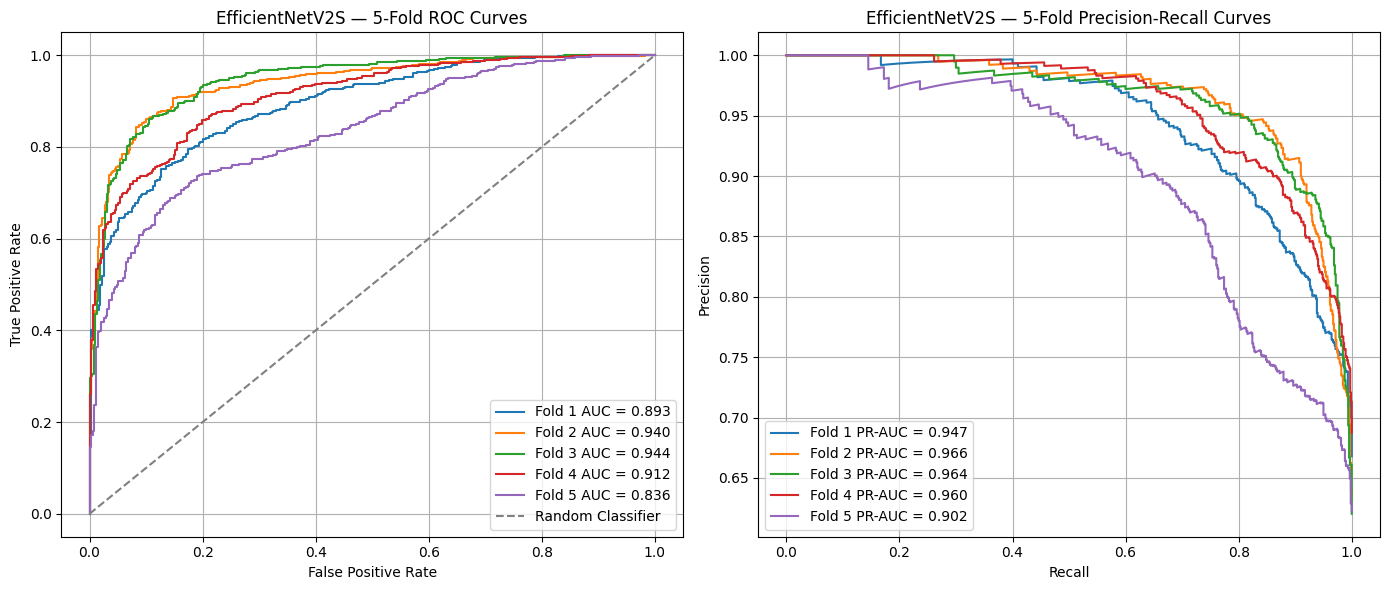

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for fold_num in range(1, 6):
    val_df, val_gen = get_val_generator(fold_num)
    model = load_model(os.path.join(MODELS_DIR, f'efficientnet_fold{fold_num}.keras'))
    val_gen.reset()
    y_true = val_gen.classes
    y_prob = model.predict(val_gen, verbose=0).ravel()

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'Fold {fold_num} AUC = {roc_auc_val:.3f}')

    # PR
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
    pr_auc_val = average_precision_score(y_true, y_prob)
    ax2.plot(recall_vals, precision_vals, label=f'Fold {fold_num} PR-AUC = {pr_auc_val:.3f}')

ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('EfficientNetV2S — 5-Fold ROC Curves')
ax1.legend()
ax1.grid(True)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('EfficientNetV2S — 5-Fold Precision-Recall Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('efficientnet_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Fold 5 hem ROC-AUC hem de PR-AUC açısından diğer fold’lara göre daha düşük performans göstermiştir. Bu durum, Fold 5 validation setinde yer alan hasta grubunun veya görüntü dağılımının daha zorlayıcı olabileceğini düşündürmektedir. Benzer şekilde DenseNet121 modelinde de Fold 5’in düşük performans göstermesi, bu durumun yalnızca EfficientNetV2S modeline özgü olmadığını göstermektedir. Her iki modelin de aynı fold’da zorlanması, Fold 5’teki performans düşüşünün model mimarisinden çok hasta bazlı ayrımın ve ilgili validation hasta grubunun zorluğundan kaynaklanabileceğini desteklemektedir. Buna rağmen Fold 5’te bile modelin ROC ve PR eğrilerinin kabul edilebilir seviyede kalması, EfficientNetV2S’in genel olarak stabil bir model olduğunu göstermektedir.


# DenseNet121 Final Test Modeli ve Analizi

In [ ]:
from collections import defaultdict
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

test_datagen = ImageDataGenerator(rescale=1./255)
MAGNIFICATIONS = ['40X', '100X', '200X', '400X']
GLOBAL_THRESHOLD = 0.5

# Sonuçları biriktirme
overall_fold_results = {}   # fold_num → {'auc', 'acc', 'cm'}
mag_fold_results = defaultdict(dict)  # mag → fold_num → {'auc', 'acc', 'cm'}

# CSV hazırlığı
full_df = pd.read_csv(FOLDS_CSV)
full_df['label'] = full_df['filename'].apply(
    lambda x: 'malignant' if 'malignant' in x else 'benign'
)
full_df['filepath'] = full_df['filename'].apply(
    lambda x: os.path.join(IMGS_PATH, x)
)
full_df['mag'] = full_df['filename'].apply(
    lambda x: os.path.basename(x).replace('.png', '').split('-')[-2] + 'X'
)
print('CSV hazır.')
print(full_df['mag'].value_counts())

CSV hazır.
mag
100X    10405
200X    10065
40X      9975
400X     9100
Name: count, dtype: int64


7909 x 5 = 39545, Folds.csv dosyasında aynı görüntüler 5 farklı fold senaryosu için tekrar listelenmektedir. Bu nedenle bu sayı eşsiz görüntü sayısını değil, fold tekrarları dahil toplam satır sayısını göstermektedir. Test değerlendirmesinde ise her fold için yalnızca ilgili fold’a ait `grp == "test"` satırları kullanılmıştır.

In [ ]:
for fold_num in range(1, 6):
    print(f"\n{'#'*55}")
    print(f"#  FOLD {fold_num} / 5 — TEST DEĞERLENDİRMESİ")
    print(f"{'#'*55}")

    # Model yükle
    model_path = os.path.join(MODELS_DIR, f"densenet_fold{fold_num}.keras")
    model = tf.keras.models.load_model(model_path)
    print(f" Model yüklendi: {model_path}")

    # O fold'un test setini al
    fold_test_df = full_df[
        (full_df['fold'] == fold_num) & (full_df['grp'] == 'test')
    ].copy().reset_index(drop=True)
    print(f"Test seti toplam: {len(fold_test_df)} görüntü")

    # ── GENEL TEST (magnification ayrımı yok) ─────────────────
    overall_gen = test_datagen.flow_from_dataframe(
        fold_test_df,
        x_col='filepath',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode='binary',
        classes=['benign', 'malignant'],
        shuffle=False
    )
    overall_gen.reset()
    y_pred_proba_all = model.predict(overall_gen, verbose=0).flatten()
    y_pred_all = (y_pred_proba_all > GLOBAL_THRESHOLD).astype(int)
    y_true_all = overall_gen.classes

    overall_auc = roc_auc_score(y_true_all, y_pred_proba_all)
    overall_acc = np.mean(y_pred_all == y_true_all)
    overall_cm  = confusion_matrix(y_true_all, y_pred_all)

    overall_fold_results[fold_num] = {
        'auc': overall_auc,
        'acc': overall_acc,
        'cm' : overall_cm,
        'y_true': y_true_all,
        'y_pred_proba': y_pred_proba_all
    }
    print(f"\n   GENEL → AUC: {overall_auc:.4f}  Acc: {overall_acc:.4f}")

    # ── MAGNİFİKASYON BAZLI TEST ──────────────────────────────
    print(f"   MAGNİFİKASYON BAZLI:")
    for mag in MAGNIFICATIONS:
        mag_df = fold_test_df[
            fold_test_df['mag'] == mag
        ].copy().reset_index(drop=True)

        if len(mag_df) == 0 or mag_df['label'].nunique() < 2:
            print(f"     {mag}: yeterli veri yok, atlanıyor")
            continue

        mag_gen = test_datagen.flow_from_dataframe(
            mag_df,
            x_col='filepath',
            y_col='label',
            target_size=IMG_SIZE,
            batch_size=BATCH,
            class_mode='binary',
            classes=['benign', 'malignant'],
            shuffle=False
        )
        mag_gen.reset()
        y_pred_proba = model.predict(mag_gen, verbose=0).flatten()
        y_pred = (y_pred_proba > GLOBAL_THRESHOLD).astype(int)
        y_true = mag_gen.classes

        auc = roc_auc_score(y_true, y_pred_proba)
        acc = np.mean(y_pred == y_true)
        cm  = confusion_matrix(y_true, y_pred)

        mag_fold_results[mag][fold_num] = {'auc': auc, 'acc': acc, 'cm': cm}
        print(f"     {mag:5s} → AUC: {auc:.4f}  Acc: {acc:.4f}  (n={len(mag_df)})")

print("\n✅ Tüm fold'ların test değerlendirmesi tamamlandı.")


#######################################################
#  FOLD 1 / 5 — TEST DEĞERLENDİRMESİ
#######################################################
 Model yüklendi: /content/drive/MyDrive/breakhis_models/densenet_fold1.keras
Test seti toplam: 2904 görüntü
Found 2904 validated image filenames belonging to 2 classes.

   GENEL → AUC: 0.9095  Acc: 0.8437
   MAGNİFİKASYON BAZLI:
Found 745 validated image filenames belonging to 2 classes.
     40X   → AUC: 0.9067  Acc: 0.8295  (n=745)
Found 760 validated image filenames belonging to 2 classes.
     100X  → AUC: 0.8981  Acc: 0.8329  (n=760)
Found 744 validated image filenames belonging to 2 classes.
     200X  → AUC: 0.9302  Acc: 0.8710  (n=744)
Found 655 validated image filenames belonging to 2 classes.
     400X  → AUC: 0.9163  Acc: 0.8412  (n=655)

#######################################################
#  FOLD 2 / 5 — TEST DEĞERLENDİRMESİ
#######################################################
 Model yüklendi: /content/drive/MyDrive/br

In [ ]:
# ── GENEL SONUÇLAR ÖZET TABLOSU ───────────────────────────────────────────
print("\n" + "="*55)
print("  GENEL TEST SONUÇLARI (DenseNet121) — 5-Fold")
print("="*55)

overall_aucs = [overall_fold_results[f]['auc'] for f in range(1, 6)]
overall_accs = [overall_fold_results[f]['acc'] for f in range(1, 6)]

for f in range(1, 6):
    print(f"  Fold {f} → AUC: {overall_fold_results[f]['auc']:.4f}  "
          f"Acc: {overall_fold_results[f]['acc']:.4f}")
print("-"*55)
print(f"  Ortalama → AUC: {np.mean(overall_aucs):.4f} ± {np.std(overall_aucs):.4f}  "
      f"Acc: {np.mean(overall_accs):.4f} ± {np.std(overall_accs):.4f}")
print("="*55)

# 5-fold toplam confusion matrix
cm_total = np.sum([overall_fold_results[f]['cm'] for f in range(1, 6)], axis=0)
print(f"\n  5-Fold Toplam Confusion Matrix:")
print(f"  TN: {cm_total[0,0]}  FP: {cm_total[0,1]}")
print(f"  FN: {cm_total[1,0]}  TP: {cm_total[1,1]}")

tn, fp, fn, tp = cm_total[0,0], cm_total[0,1], cm_total[1,0], cm_total[1,1]
print(f"\n  Benign Specificity  : {tn/(tn+fp):.4f}")
print(f"  Malignant Recall    : {tp/(tp+fn):.4f}")
print(f"  Balanced Accuracy   : {((tn/(tn+fp)) + (tp/(tp+fn)))/2:.4f}")


  GENEL TEST SONUÇLARI (DenseNet121) — 5-Fold
  Fold 1 → AUC: 0.9095  Acc: 0.8437
  Fold 2 → AUC: 0.9345  Acc: 0.8689
  Fold 3 → AUC: 0.9487  Acc: 0.8855
  Fold 4 → AUC: 0.8257  Acc: 0.7850
  Fold 5 → AUC: 0.8886  Acc: 0.8148
-------------------------------------------------------
  Ortalama → AUC: 0.9014 ± 0.0431  Acc: 0.8396 ± 0.0363

  5-Fold Toplam Confusion Matrix:
  TN: 3363  FP: 1152
  FN: 1063  TP: 8087

  Benign Specificity  : 0.7449
  Malignant Recall    : 0.8838
  Balanced Accuracy   : 0.8143


Validation’da AUC yaklaşık 0.8820 idi, testte 0.9014 gelmiş. Yani model test setinde de genelleme yapabiliyor.

Final test aşamasında DenseNet121 modeli her fold’un bağımsız test seti üzerinde değerlendirilmiştir. Model, 5-fold test sonucunda ortalama 0.9014 ± 0.0431 ROC-AUC ve 0.8396 ± 0.0363 accuracy elde etmiştir. Bu sonuçlar, modelin validation aşamasında gösterdiği performansı test verisi üzerinde de koruduğunu ve benign-malignant ayrımında güçlü bir genelleme kapasitesine sahip olduğunu göstermektedir.

Toplam confusion matrix incelendiğinde malignant recall değeri 0.8838, benign specificity değeri ise 0.7449 olarak bulunmuştur. Modelin malignant sınıfını yüksek oranda doğru yakaladığı, ancak bazı benign örnekleri malignant olarak sınıflandırdığı görülmektedir. Bu durum, modelin kötü huylu örnekleri kaçırmamaya daha yatkın davrandığını ve false positive hatalarının false negative hatalarına göre yorumlanması gerektiğini göstermektedir.

In [ ]:
# ── MAGNİFİKASYON BAZLI ÖZET TABLOSU ─────────────────────────────────────
print("\n" + "="*70)
print("  MAGNİFİKASYON BAZLI SONUÇLAR (DenseNet121) — 5-Fold Ortalama")
print("="*70)

mag_summary = {}
for mag in MAGNIFICATIONS:
    if mag not in mag_fold_results:
        continue
    fold_data = mag_fold_results[mag]
    aucs = [fold_data[f]['auc'] for f in fold_data]
    accs = [fold_data[f]['acc'] for f in fold_data]
    mean_auc, std_auc = np.mean(aucs), np.std(aucs)
    mean_acc, std_acc = np.mean(accs), np.std(accs)
    mag_summary[mag] = (mean_auc, std_auc, mean_acc, std_acc)
    fold_str = '  '.join([f'F{f}:{aucs[i]:.3f}' for i, f in enumerate(fold_data)])
    print(f"  {mag:5s}  AUC: {mean_auc:.4f} ± {std_auc:.4f}  "
          f"Acc: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"         Fold bazlı → {fold_str}")
print("-"*70)
all_aucs = [v[0] for v in mag_summary.values()]
print(f"  Genel    AUC: {np.mean(all_aucs):.4f} ± {np.std(all_aucs):.4f}")
print("="*70)


  MAGNİFİKASYON BAZLI SONUÇLAR (DenseNet121) — 5-Fold Ortalama
  40X    AUC: 0.8947 ± 0.0421  Acc: 0.8258 ± 0.0397
         Fold bazlı → F1:0.907  F2:0.933  F3:0.941  F4:0.832  F5:0.861
  100X   AUC: 0.8991 ± 0.0493  Acc: 0.8455 ± 0.0403
         Fold bazlı → F1:0.898  F2:0.926  F3:0.966  F4:0.817  F5:0.889
  200X   AUC: 0.9262 ± 0.0457  Acc: 0.8634 ± 0.0358
         Fold bazlı → F1:0.930  F2:0.964  F3:0.973  F4:0.844  F5:0.920
  400X   AUC: 0.9031 ± 0.0288  Acc: 0.8220 ± 0.0340
         Fold bazlı → F1:0.916  F2:0.929  F3:0.908  F4:0.847  F5:0.915
----------------------------------------------------------------------
  Genel    AUC: 0.9058 ± 0.0122


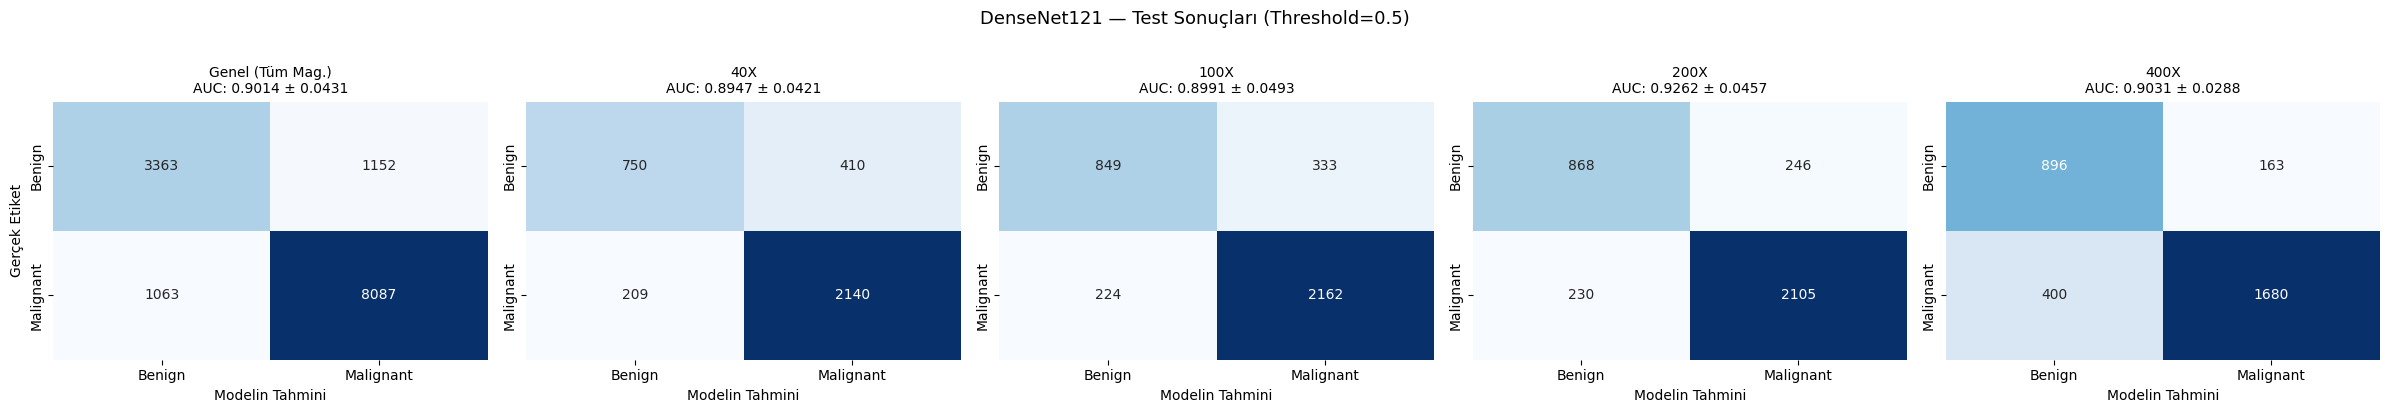

💾 densenet_final_test_results.png kaydedildi.


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4))

# Sol: Genel 5-fold toplam CM
sns.heatmap(
    cm_total, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant'],
    ax=axes[0], cbar=False
)
axes[0].set_title(
    f"Genel (Tüm Mag.)\nAUC: {np.mean(overall_aucs):.4f} ± {np.std(overall_aucs):.4f}",
    fontsize=10
)
axes[0].set_xlabel('Modelin Tahmini')
axes[0].set_ylabel('Gerçek Etiket')

# Sağ 4: Magnification bazlı
for idx, mag in enumerate(MAGNIFICATIONS):
    ax = axes[idx + 1]
    if mag not in mag_fold_results:
        ax.axis('off')
        continue
    cms = [mag_fold_results[mag][f]['cm'] for f in mag_fold_results[mag]]
    cm_sum = np.sum(cms, axis=0)
    mean_auc, std_auc = mag_summary[mag][0], mag_summary[mag][1]
    sns.heatmap(
        cm_sum, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Benign', 'Malignant'],
        yticklabels=['Benign', 'Malignant'],
        ax=ax, cbar=False
    )
    ax.set_title(f"{mag}\nAUC: {mean_auc:.4f} ± {std_auc:.4f}", fontsize=10)
    ax.set_xlabel('Modelin Tahmini')
    ax.set_ylabel('')

plt.suptitle(
    f'DenseNet121 — Test Sonuçları (Threshold={GLOBAL_THRESHOLD})',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('densenet_final_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 densenet_final_test_results.png kaydedildi.')

Magnification bazlı test sonuçları incelendiğinde, DenseNet121 modelinin en yüksek performansı **200X** büyütme seviyesinde elde ettiği görülmektedir. 200X magnification için ortalama AUC değeri **0.9262 ± 0.0457**, accuracy değeri ise **0.8634 ± 0.0358** olarak hesaplanmıştır. Bu değerler 40X, 100X ve 400X büyütme seviyelerine göre daha yüksektir.

Bu sonuç, modelin 200X büyütme seviyesinde benign ve malignant sınıfları ayırt etmek için daha güçlü histopatolojik özellikler öğrenebildiğini göstermektedir. Elde edilen bulgu literatürdeki önceki çalışmalarla da uyumludur. Ashtaiwi (2022), histopatolojik görüntülerde en uygun magnification seviyelerini incelediği çalışmasında, özellikle **200X ve üzeri büyütme faktörlerinin** derin öğrenme tabanlı meme kanseri tahmini için daha başarılı sonuçlar verdiğini belirtmiştir. Bizim çalışmamızda da en yüksek AUC ve accuracy değerlerinin 200X seviyesinde elde edilmesi, bu literatür bulgusunu desteklemektedir.

Referans: Ashtaiwi, A. *Optimal Histopathological Magnification Factors for Deep Learning-Based Breast Cancer Prediction*. Applied System Innovation, 2022, 5(5), 87. https://doi.org/10.3390/asi5050087


# EfficientNetV2S Final Test Modeli ve Analizi

In [19]:
MAGNIFICATIONS = ['40X', '100X', '200X', '400X']

overall_fold_results = {}
mag_fold_results     = defaultdict(dict)

# Folds.csv'yi hazırla
full_df = pd.read_csv(FOLDS_CSV)
full_df['label'] = full_df['filename'].apply(
    lambda x: 'malignant' if 'malignant' in x else 'benign'
)
full_df['filepath'] = full_df['filename'].apply(
    lambda x: os.path.join(IMGS_PATH, x)
)
full_df['mag'] = full_df['filename'].apply(
    lambda x: os.path.basename(x).replace('.png', '').split('-')[-2] + 'X'
)
print('CSV hazır.')
print(full_df['mag'].value_counts())

CSV hazır.
mag
100X    10405
200X    10065
40X      9975
400X     9100
Name: count, dtype: int64


7909 x 5 = 39545, Folds.csv dosyasında aynı görüntüler 5 farklı fold senaryosu için tekrar listelenmektedir. Bu nedenle bu sayı eşsiz görüntü sayısını değil, fold tekrarları dahil toplam satır sayısını göstermektedir. Test değerlendirmesinde ise her fold için yalnızca ilgili fold’a ait `grp == "test"` satırları kullanılmıştır.

In [25]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)
GLOBAL_THRESHOLD=0.5
for fold_num in range(1, 6):
    print(f"\n{'#'*55}")
    print(f'#  FOLD {fold_num} / 5 — TEST DEĞERLENDİRMESİ')
    print(f"{'#'*55}")

    model_path = os.path.join(MODELS_DIR, f'efficientnet_fold{fold_num}.keras')
    model = tf.keras.models.load_model(model_path)
    print(f' Model yüklendi: {model_path}')

    fold_test_df = full_df[
        (full_df['fold'] == fold_num) & (full_df['grp'] == 'test')
    ].copy().reset_index(drop=True)
    print(f'Test seti toplam: {len(fold_test_df)} görüntü')

    # ── GENEL TEST ────────────────────────────────────────────
    overall_gen = test_datagen.flow_from_dataframe(
        fold_test_df, x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH,
        class_mode='binary', classes=['benign', 'malignant'],
        shuffle=False
    )
    overall_gen.reset()
    y_pred_proba_all = model.predict(overall_gen, verbose=0).flatten()
    y_pred_all = (y_pred_proba_all > GLOBAL_THRESHOLD).astype(int)
    y_true_all = overall_gen.classes

    overall_auc = roc_auc_score(y_true_all, y_pred_proba_all)
    overall_acc = np.mean(y_pred_all == y_true_all)
    overall_cm  = confusion_matrix(y_true_all, y_pred_all)

    overall_fold_results[fold_num] = {
        'auc': overall_auc, 'acc': overall_acc,
        'cm': overall_cm,
        'y_true': y_true_all, 'y_pred_proba': y_pred_proba_all
    }
    print(f'\n    GENEL → AUC: {overall_auc:.4f}  Acc: {overall_acc:.4f}')

    # ── MAGNİFİKASYON BAZLI TEST ──────────────────────────────
    print(f'    MAGNİFİKASYON BAZLI:')
    for mag in MAGNIFICATIONS:
        mag_df = fold_test_df[fold_test_df['mag'] == mag].copy().reset_index(drop=True)
        if len(mag_df) == 0 or mag_df['label'].nunique() < 2:
            print(f'     {mag}: yeterli veri yok, atlanıyor')
            continue
        mag_gen = test_datagen.flow_from_dataframe(
            mag_df, x_col='filepath', y_col='label',
            target_size=IMG_SIZE, batch_size=BATCH,
            class_mode='binary', classes=['benign', 'malignant'],
            shuffle=False
        )
        mag_gen.reset()
        y_pred_proba = model.predict(mag_gen, verbose=0).flatten()
        y_pred = (y_pred_proba > GLOBAL_THRESHOLD).astype(int)
        y_true = mag_gen.classes
        auc_val = roc_auc_score(y_true, y_pred_proba)
        acc_val = np.mean(y_pred == y_true)
        cm_val  = confusion_matrix(y_true, y_pred)
        mag_fold_results[mag][fold_num] = {'auc': auc_val, 'acc': acc_val, 'cm': cm_val}
        print(f'     {mag:5s} → AUC: {auc_val:.4f}  Acc: {acc_val:.4f}  (n={len(mag_df)})')

print('\n Tüm fold\'ların test değerlendirmesi tamamlandı.')


#######################################################
#  FOLD 1 / 5 — TEST DEĞERLENDİRMESİ
#######################################################
 Model yüklendi: /content/drive/MyDrive/breakhis_models_efficientnet/efficientnet_fold1.keras
Test seti toplam: 2904 görüntü
Found 2904 validated image filenames belonging to 2 classes.

    GENEL → AUC: 0.9175  Acc: 0.8495
    MAGNİFİKASYON BAZLI:
Found 745 validated image filenames belonging to 2 classes.
     40X   → AUC: 0.9263  Acc: 0.8537  (n=745)
Found 760 validated image filenames belonging to 2 classes.
     100X  → AUC: 0.9183  Acc: 0.8408  (n=760)
Found 744 validated image filenames belonging to 2 classes.
     200X  → AUC: 0.9313  Acc: 0.8669  (n=744)
Found 655 validated image filenames belonging to 2 classes.
     400X  → AUC: 0.8899  Acc: 0.8351  (n=655)

#######################################################
#  FOLD 2 / 5 — TEST DEĞERLENDİRMESİ
#######################################################
 Model yüklendi: /conte

In [26]:
# ── GENEL SONUÇLAR ÖZET TABLOSU ───────────────────────────────────────────
print('\n' + '='*55)
print('  GENEL TEST SONUÇLARI (EfficientNetV2S) — 5-Fold')
print('='*55)
overall_aucs = [overall_fold_results[f]['auc'] for f in range(1, 6)]
overall_accs = [overall_fold_results[f]['acc'] for f in range(1, 6)]
for f in range(1, 6):
    print(f"  Fold {f} → AUC: {overall_fold_results[f]['auc']:.4f}  "
          f"Acc: {overall_fold_results[f]['acc']:.4f}")
print('-'*55)
print(f'  Ortalama → AUC: {np.mean(overall_aucs):.4f} ± {np.std(overall_aucs):.4f}  '
      f'Acc: {np.mean(overall_accs):.4f} ± {np.std(overall_accs):.4f}')
print('='*55)

cm_total = np.sum([overall_fold_results[f]['cm'] for f in range(1, 6)], axis=0)
tn, fp, fn, tp = cm_total[0,0], cm_total[0,1], cm_total[1,0], cm_total[1,1]
print(f'\n  5-Fold Toplam Confusion Matrix:')
print(f'  TN: {tn}  FP: {fp}')
print(f'  FN: {fn}  TP: {tp}')
print(f'\n  Benign Specificity : {tn/(tn+fp):.4f}')
print(f'  Malignant Recall   : {tp/(tp+fn):.4f}')
print(f'  Balanced Accuracy  : {((tn/(tn+fp))+(tp/(tp+fn)))/2:.4f}')


  GENEL TEST SONUÇLARI (EfficientNetV2S) — 5-Fold
  Fold 1 → AUC: 0.9175  Acc: 0.8495
  Fold 2 → AUC: 0.9162  Acc: 0.8290
  Fold 3 → AUC: 0.9380  Acc: 0.8607
  Fold 4 → AUC: 0.9210  Acc: 0.8558
  Fold 5 → AUC: 0.9306  Acc: 0.8712
-------------------------------------------------------
  Ortalama → AUC: 0.9247 ± 0.0084  Acc: 0.8532 ± 0.0141

  5-Fold Toplam Confusion Matrix:
  TN: 3676  FP: 839
  FN: 1154  TP: 7996

  Benign Specificity : 0.8142
  Malignant Recall   : 0.8739
  Balanced Accuracy  : 0.8440


EfficientNetV2S modeli final test setleri üzerinde değerlendirildiğinde ortalama **0.9247 ± 0.0084 ROC-AUC** ve **0.8532 ± 0.0141 accuracy** elde etmiştir. Bu sonuçlar, EfficientNetV2S modelinin test verisi üzerinde güçlü bir genelleme performansı gösterdiğini ortaya koymaktadır. Ayrıca AUC ve accuracy standart sapmalarının düşük olması, modelin fold’lar arasında DenseNet121’e kıyasla daha stabil performans sergilediğini göstermektedir.

Toplam test confusion matrix sonuçları incelendiğinde EfficientNetV2S modelinin **benign specificity** değerinin **0.8142**, **malignant recall** değerinin ise **0.8739** olduğu görülmektedir. Bu durum, modelin benign sınıfını DenseNet121’e göre daha başarılı ayırdığını, ancak malignant sınıfını yakalama oranında DenseNet121’e göre küçük bir düşüş olduğunu göstermektedir.

DenseNet121 ile karşılaştırıldığında EfficientNetV2S modeli false positive sayısını **1152’den 839’a** düşürmüştür. Bu sonuç, EfficientNetV2S’in benign örnekleri malignant olarak sınıflandırma eğilimini belirgin şekilde azalttığını göstermektedir. Buna karşılık false negative sayısı **1063’ten 1154’e** yükselmiştir. Dolayısıyla EfficientNetV2S daha yüksek AUC, accuracy, benign specificity ve balanced accuracy değerleriyle daha dengeli bir performans gösterirken; DenseNet121 malignant recall açısından az farkla daha avantajlı kalmıştır.

Genel olarak EfficientNetV2S, final test sonuçlarında DenseNet121’e göre daha yüksek ve daha stabil AUC performansı elde etmiştir. Ancak nihai model seçimi yapılırken yalnızca AUC değeri değil, malignant recall, benign specificity ve false negative/false positive dengesi birlikte değerlendirilmelidir. İki model arasındaki AUC farkının istatistiksel olarak anlamlı olup olmadığını değerlendirmek için aynı test örnekleri üzerindeki tahmin olasılıkları kullanılarak DeLong testi uygulanacaktır.


In [27]:
# ── MAGNİFİKASYON BAZLI ÖZET TABLOSU ─────────────────────────────────────
print('\n' + '='*70)
print('  MAGNİFİKASYON BAZLI SONUÇLAR (EfficientNetV2S) — 5-Fold Ortalama')
print('='*70)
mag_summary = {}
for mag in MAGNIFICATIONS:
    if mag not in mag_fold_results:
        continue
    fold_data = mag_fold_results[mag]
    aucs = [fold_data[f]['auc'] for f in fold_data]
    accs = [fold_data[f]['acc'] for f in fold_data]
    mean_auc, std_auc = np.mean(aucs), np.std(aucs)
    mean_acc, std_acc = np.mean(accs), np.std(accs)
    mag_summary[mag] = (mean_auc, std_auc, mean_acc, std_acc)
    fold_str = '  '.join([f'F{f}:{aucs[i]:.3f}' for i, f in enumerate(fold_data)])
    print(f'  {mag:5s}  AUC: {mean_auc:.4f} ± {std_auc:.4f}  Acc: {mean_acc:.4f} ± {std_acc:.4f}')
    print(f'         Fold bazlı → {fold_str}')
print('-'*70)
all_aucs = [v[0] for v in mag_summary.values()]
print(f'  Genel    AUC: {np.mean(all_aucs):.4f} ± {np.std(all_aucs):.4f}')
print('='*70)


  MAGNİFİKASYON BAZLI SONUÇLAR (EfficientNetV2S) — 5-Fold Ortalama
  40X    AUC: 0.9177 ± 0.0143  Acc: 0.8537 ± 0.0174
         Fold bazlı → F1:0.926  F2:0.894  F3:0.925  F4:0.908  F5:0.934
  100X   AUC: 0.9218 ± 0.0203  Acc: 0.8456 ± 0.0228
         Fold bazlı → F1:0.918  F2:0.901  F3:0.956  F4:0.902  F5:0.932
  200X   AUC: 0.9455 ± 0.0096  Acc: 0.8731 ± 0.0149
         Fold bazlı → F1:0.931  F2:0.949  F3:0.960  F4:0.940  F5:0.947
  400X   AUC: 0.9149 ± 0.0184  Acc: 0.8399 ± 0.0267
         Fold bazlı → F1:0.890  F2:0.928  F3:0.903  F4:0.942  F5:0.912
----------------------------------------------------------------------
  Genel    AUC: 0.9250 ± 0.0121


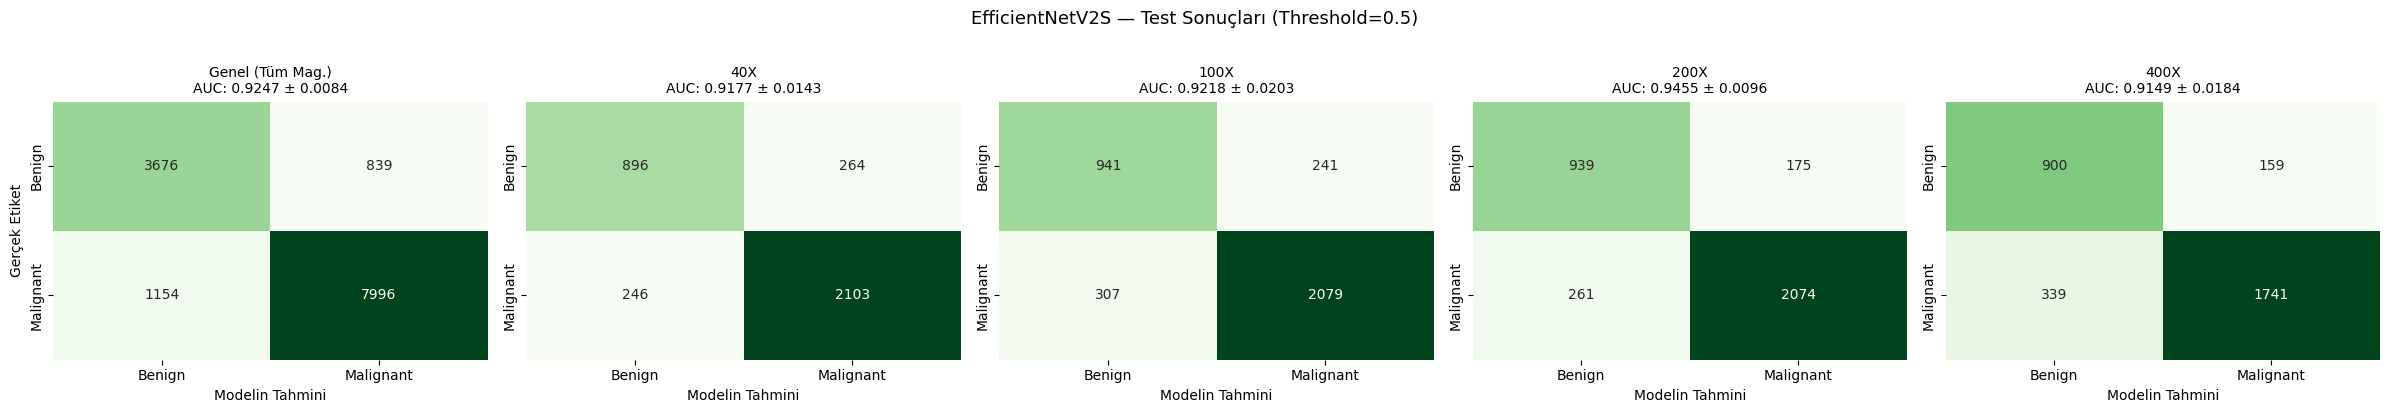

💾 efficientnet_final_test_results.png kaydedildi.


In [28]:
# ── GÖRSELLEŞTİRME ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 4))

sns.heatmap(cm_total, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            ax=axes[0], cbar=False)
axes[0].set_title(
    f'Genel (Tüm Mag.)\nAUC: {np.mean(overall_aucs):.4f} ± {np.std(overall_aucs):.4f}',
    fontsize=10)
axes[0].set_xlabel('Modelin Tahmini')
axes[0].set_ylabel('Gerçek Etiket')

for idx, mag in enumerate(MAGNIFICATIONS):
    ax = axes[idx + 1]
    if mag not in mag_fold_results:
        ax.axis('off')
        continue
    cms = [mag_fold_results[mag][f]['cm'] for f in mag_fold_results[mag]]
    cm_sum = np.sum(cms, axis=0)
    mean_auc, std_auc = mag_summary[mag][0], mag_summary[mag][1]
    sns.heatmap(cm_sum, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                ax=ax, cbar=False)
    ax.set_title(f'{mag}\nAUC: {mean_auc:.4f} ± {std_auc:.4f}', fontsize=10)
    ax.set_xlabel('Modelin Tahmini')
    ax.set_ylabel('')

plt.suptitle(f'EfficientNetV2S — Test Sonuçları (Threshold={GLOBAL_THRESHOLD})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('efficientnet_final_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 efficientnet_final_test_results.png kaydedildi.')

EfficientNetV2S modelinin magnification bazlı test sonuçları incelendiğinde, en yüksek performansın **200X** büyütme seviyesinde elde edildiği görülmektedir. 200X magnification için ortalama AUC değeri **0.9455 ± 0.0096**, accuracy değeri ise **0.8731 ± 0.0149** olarak hesaplanmıştır. Bu değerler 40X, 100X ve 400X büyütme seviyelerine göre daha yüksektir.

Bu bulgu, DenseNet121 modelinde elde edilen magnification sonuçlarıyla da tutarlıdır. DenseNet121’de de en yüksek AUC ve accuracy değerleri 200X büyütme seviyesinde elde edilmiştir. Dolayısıyla 200X magnification seviyesinin yalnızca belirli bir model mimarisine özgü olarak değil, genel olarak benign ve malignant ayrımında daha ayırt edici histopatolojik özellikler sunduğu söylenebilir.

Ayrıca EfficientNetV2S, tüm magnification seviyelerinde DenseNet121’e göre daha yüksek AUC değerleri üretmiştir. Özellikle 200X büyütmede AUC değerinin 0.9262’den 0.9455’e yükselmesi, EfficientNetV2S’in bu büyütme seviyesindeki dokusal ve hücresel özellikleri daha etkili kullandığını göstermektedir.

Bu sonuçlarda yine literatürle de uyumludur. Ashtaiwi (2022), histopatolojik görüntülerde magnification faktörlerini incelediği çalışmasında, **200X ve üzeri büyütme seviyelerinin** derin öğrenme tabanlı meme kanseri tahmininde daha başarılı sonuçlar verdiğini belirtmiştir. Bizim çalışmamızda hem DenseNet121 hem de EfficientNetV2S modellerinde en iyi performansın 200X seviyesinde elde edilmesi, bu literatür bulgusunu desteklemektedir.

Referans: Ashtaiwi, A. *Optimal Histopathological Magnification Factors for Deep Learning-Based Breast Cancer Prediction*. Applied System Innovation, 2022, 5(5), 87. https://doi.org/10.3390/asi5050087


# DeLong Testi — DenseNet121 vs EfficientNetV2S


Her fold için aynı test seti üzerinde iki modelin AUC'si karşılaştırılır.

p-value < 0.05 → fark istatistiksel olarak anlamlı.

In [35]:
IMGS_PATH = "/content/breakhis/BreaKHis_v1"



import pandas as pd, os

SPLIT_DIR = "Split_Dataframes"



for fold_num in range(1, 6):

    for split in ['train', 'val']:

        path = os.path.join(SPLIT_DIR, f"fold{fold_num}_{split}.csv")

        df = pd.read_csv(path)

        df['filepath'] = df['filename'].apply(

            lambda x: os.path.join(IMGS_PATH, x)

        )

        df.to_csv(path, index=False)

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from sklearn.metrics import roc_auc_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from scipy import stats

# ── Yollar (önceki notebook'larla aynı) ──────────────────────

DENSE_DIR   = '/content/drive/MyDrive/breakhis_models'
EFFNET_DIR  = '/content/drive/MyDrive/breakhis_models_efficientnet'
IMG_SIZE    = (224, 224)
BATCH       = 32
MAGNIFICATIONS = ['40X', '100X', '200X', '400X']

test_datagen = ImageDataGenerator(rescale=1./255)

# Folds.csv hazırlığı
full_df = pd.read_csv(FOLDS_CSV)
full_df['label'] = full_df['filename'].apply(
    lambda x: 'malignant' if 'malignant' in x else 'benign'
)
full_df['filepath'] = full_df['filename'].apply(
    lambda x: os.path.join(IMGS_PATH, x)
)
full_df['mag'] = full_df['filename'].apply(
    lambda x: os.path.basename(x).replace('.png', '').split('-')[-2] + 'X'
)
print('✅ Hazırlık tamamlandı.')
print(f'Örnek filepath var mı? {os.path.exists(full_df["filepath"].iloc[0])}')

✅ Hazırlık tamamlandı.
Örnek filepath var mı? True


In [39]:
# ── DeLong Testi Implementasyonu ──────────────────────────────────────────
# Kaynak: DeLong et al. (1988) — Comparing the Areas Under Two or More
# Correlated Receiver Operating Characteristic Curves

def compute_midrank(x):
    """Sıralama için midrank hesapla."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2


def fastDeLong(predictions_sorted_transposed, label_1_count):
    """FastDeLong algoritması: AUC ve kovaryans matrisini hesaplar."""
    m = label_1_count       # pozitif (malignant) sayısı
    n = predictions_sorted_transposed.shape[1] - m  # negatif (benign) sayısı
    k = predictions_sorted_transposed.shape[0]       # model sayısı

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tx[r, :] = compute_midrank(predictions_sorted_transposed[r, :m])
        ty[r, :] = compute_midrank(predictions_sorted_transposed[r, m:])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = (tz[:, :m].sum(axis=1) - tx.sum(axis=1)) / (m * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n

    return aucs, delongcov


def delong_roc_test(y_true, y_pred_1, y_pred_2):
    """
    İki modelin AUC'sini DeLong testiyle karşılaştırır.
    Döndürür: (auc1, auc2, z_score, p_value)
    """
    # Numpy array'e çevir
    y_true   = np.array(y_true)
    y_pred_1 = np.array(y_pred_1)
    y_pred_2 = np.array(y_pred_2)

    # Pozitif örnekleri öne al
    order = np.argsort(-y_true)
    label_1_count = int(y_true.sum())

    predictions_sorted = np.vstack([
        y_pred_1[order],
        y_pred_2[order]
    ])

    aucs, delongcov = fastDeLong(predictions_sorted, label_1_count)

    auc_diff = aucs[0] - aucs[1]
    var_diff = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]
    z_score  = auc_diff / np.sqrt(var_diff)
    p_value  = 2 * stats.norm.sf(abs(z_score))

    return aucs[0], aucs[1], z_score, p_value


print(' DeLong testi fonksiyonu tanımlandı.')

 DeLong testi fonksiyonu tanımlandı.


Bu çalışmada DeLong et al. (1988) tarafından önerilen “Comparing the Areas Under Two or More Correlated Receiver Operating Characteristic Curves” yaklaşımı temel alınarak FastDeLong algoritması uygulanmıştır.

Karşılaştırmanın adil yapılabilmesi için iki model de aynı test fold’ları üzerinde değerlendirilmiş, test generator’larında shuffle=False kullanılarak örnek sırasının aynı kalması sağlanmıştır. Böylece DenseNet121 ve EfficientNetV2S modellerinin aynı görüntüler üzerindeki tahmin olasılıkları eşleştirilmiş şekilde karşılaştırılmıştır.

In [40]:
delong_results = []


all_y_true_combined  = []
all_dense_combined   = []
all_effnet_combined  = []

for fold_num in range(1, 6):
    print(f"\n{'='*55}")
    print(f'  FOLD {fold_num} / 5')
    print(f"{'='*55}")

    # Test setini al
    fold_test_df = full_df[
        (full_df['fold'] == fold_num) & (full_df['grp'] == 'test')
    ].copy().reset_index(drop=True)
    print(f'Test seti: {len(fold_test_df)} görüntü')


    gen = test_datagen.flow_from_dataframe(
        fold_test_df, x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH,
        class_mode='binary', classes=['benign', 'malignant'],
        shuffle=False
    )
    y_true = gen.classes

    # DenseNet tahminleri
    dense_model = tf.keras.models.load_model(
        os.path.join(DENSE_DIR, f'densenet_fold{fold_num}.keras')
    )
    gen.reset()
    y_pred_dense = dense_model.predict(gen, verbose=0).flatten()
    del dense_model

    # EfficientNet tahminleri
    effnet_model = tf.keras.models.load_model(
        os.path.join(EFFNET_DIR, f'efficientnet_fold{fold_num}.keras')
    )
    gen.reset()
    y_pred_effnet = effnet_model.predict(gen, verbose=0).flatten()
    del effnet_model

    # AUC
    auc_dense  = roc_auc_score(y_true, y_pred_dense)
    auc_effnet = roc_auc_score(y_true, y_pred_effnet)

    # DeLong testi
    _, _, z_score, p_value = delong_roc_test(y_true, y_pred_dense, y_pred_effnet)

    significance = ' Anlamlı (p<0.05)' if p_value < 0.05 else '❌ Anlamlı değil (p≥0.05)'
    winner = 'DenseNet121' if auc_dense > auc_effnet else 'EfficientNetV2S'

    print(f'  DenseNet121     AUC: {auc_dense:.4f}')
    print(f'  EfficientNetV2S AUC: {auc_effnet:.4f}')
    print(f'  Z-score: {z_score:.4f}  p-value: {p_value:.4f}')
    print(f'  {significance} → Kazanan: {winner}')

    delong_results.append({
        'fold': fold_num,
        'auc_dense': auc_dense,
        'auc_effnet': auc_effnet,
        'auc_diff': auc_dense - auc_effnet,
        'z_score': z_score,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'winner': winner
    })


    all_y_true_combined.extend(y_true)
    all_dense_combined.extend(y_pred_dense)
    all_effnet_combined.extend(y_pred_effnet)

print('\n Tüm fold DeLong testleri tamamlandı.')


  FOLD 1 / 5
Test seti: 2904 görüntü
Found 2904 validated image filenames belonging to 2 classes.
  DenseNet121     AUC: 0.9095
  EfficientNetV2S AUC: 0.9175
  Z-score: -1.7436  p-value: 0.0812
  ❌ Anlamlı değil (p≥0.05) → Kazanan: EfficientNetV2S

  FOLD 2 / 5
Test seti: 2403 görüntü
Found 2403 validated image filenames belonging to 2 classes.
  DenseNet121     AUC: 0.9345
  EfficientNetV2S AUC: 0.9162
  Z-score: 3.8651  p-value: 0.0001
   Anlamlı (p<0.05) → Kazanan: DenseNet121

  FOLD 3 / 5
Test seti: 2577 görüntü
Found 2577 validated image filenames belonging to 2 classes.
  DenseNet121     AUC: 0.9487
  EfficientNetV2S AUC: 0.9380
  Z-score: 2.3116  p-value: 0.0208
   Anlamlı (p<0.05) → Kazanan: DenseNet121

  FOLD 4 / 5
Test seti: 2698 görüntü
Found 2698 validated image filenames belonging to 2 classes.
  DenseNet121     AUC: 0.8257
  EfficientNetV2S AUC: 0.9210
  Z-score: -12.4659  p-value: 0.0000
   Anlamlı (p<0.05) → Kazanan: EfficientNetV2S

  FOLD 5 / 5
Test seti: 3083 görü

In [41]:
results_df = pd.DataFrame(delong_results)

print('\n' + '='*70)
print('  DELONG TESTİ SONUÇLARI — DenseNet121 vs EfficientNetV2S')
print('='*70)
print(f'  {"Fold":<6} {"Dense AUC":<12} {"EffNet AUC":<13} {"Fark":<8} {"p-value":<10} {"Anlamlı?"}')
print('-'*70)
for _, row in results_df.iterrows():
    sig = '✅' if row['significant'] else '❌'
    print(f"  Fold {int(row['fold'])}  "
          f"{row['auc_dense']:.4f}       "
          f"{row['auc_effnet']:.4f}        "
          f"{row['auc_diff']:+.4f}  "
          f"{row['p_value']:.4f}     "
          f"{sig}")
print('-'*70)
print(f"  Ort.   "
      f"{results_df['auc_dense'].mean():.4f} "
      f"± {results_df['auc_dense'].std():.4f}  "
      f"{results_df['auc_effnet'].mean():.4f} "
      f"± {results_df['auc_effnet'].std():.4f}")
print('='*70)

# Tüm test seti üzerinde global DeLong
all_y_true  = np.array(all_y_true_combined)
all_dense   = np.array(all_dense_combined)
all_effnet  = np.array(all_effnet_combined)

_, _, z_global, p_global = delong_roc_test(all_y_true, all_dense, all_effnet)
auc_dense_global  = roc_auc_score(all_y_true, all_dense)
auc_effnet_global = roc_auc_score(all_y_true, all_effnet)

print(f'\n  GLOBAL (5-Fold Birleşik) DeLong Testi:')
print(f'  DenseNet121     AUC: {auc_dense_global:.4f}')
print(f'  EfficientNetV2S AUC: {auc_effnet_global:.4f}')
print(f'  Z-score: {z_global:.4f}  p-value: {p_global:.4f}')
if p_global < 0.05:
    winner = "DenseNet121" if auc_dense_global > auc_effnet_global else "EfficientNetV2S"
    print(f'  ✅ Fark istatistiksel olarak anlamlı (p<0.05) → {winner} daha iyi.')
else:
    print(f'  ❌ Fark istatistiksel olarak anlamlı değil (p={p_global:.4f}).')
    print(f'     İki model istatistiksel olarak eşit kabul edilir.')


  DELONG TESTİ SONUÇLARI — DenseNet121 vs EfficientNetV2S
  Fold   Dense AUC    EffNet AUC    Fark     p-value    Anlamlı?
----------------------------------------------------------------------
  Fold 1  0.9095       0.9175        -0.0079  0.0812     ❌
  Fold 2  0.9345       0.9162        +0.0183  0.0001     ✅
  Fold 3  0.9487       0.9380        +0.0107  0.0208     ✅
  Fold 4  0.8257       0.9210        -0.0953  0.0000     ✅
  Fold 5  0.8886       0.9306        -0.0421  0.0000     ✅
----------------------------------------------------------------------
  Ort.   0.9014 ± 0.0482  0.9247 ± 0.0094

  GLOBAL (5-Fold Birleşik) DeLong Testi:
  DenseNet121     AUC: 0.9016
  EfficientNetV2S AUC: 0.9208
  Z-score: -7.9044  p-value: 0.0000
  ✅ Fark istatistiksel olarak anlamlı (p<0.05) → EfficientNetV2S daha iyi.


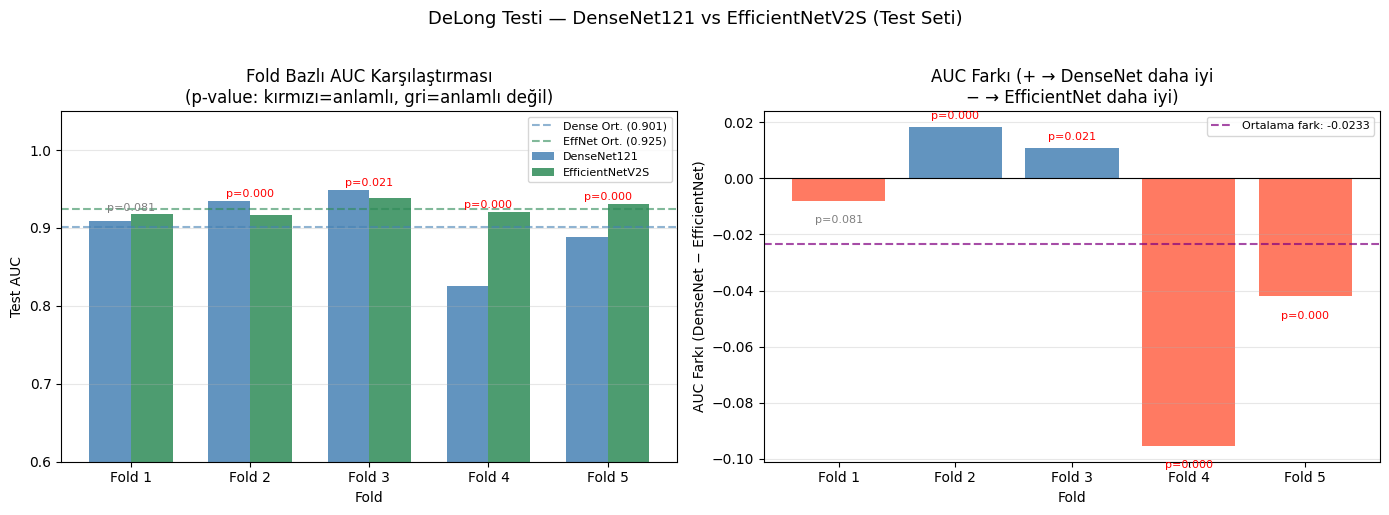

💾 delong_comparison.png kaydedildi.


In [42]:
# ── Görselleştirme ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Fold bazlı AUC karşılaştırması
x = np.arange(1, 6)
width = 0.35
bars1 = ax1.bar(x - width/2, results_df['auc_dense'],  width,
                label='DenseNet121', color='steelblue', alpha=0.85)
bars2 = ax1.bar(x + width/2, results_df['auc_effnet'], width,
                label='EfficientNetV2S', color='seagreen', alpha=0.85)

# p-value annotasyonları
for i, row in results_df.iterrows():
    y_pos = max(row['auc_dense'], row['auc_effnet']) + 0.005
    sig_text = f"p={row['p_value']:.3f}"
    color = 'red' if row['significant'] else 'gray'
    ax1.text(i + 1, y_pos, sig_text, ha='center', fontsize=8, color=color)

ax1.axhline(y=results_df['auc_dense'].mean(),  linestyle='--',
            color='steelblue', alpha=0.6, label=f'Dense Ort. ({results_df["auc_dense"].mean():.3f})')
ax1.axhline(y=results_df['auc_effnet'].mean(), linestyle='--',
            color='seagreen',  alpha=0.6, label=f'EffNet Ort. ({results_df["auc_effnet"].mean():.3f})')
ax1.set_xlabel('Fold')
ax1.set_ylabel('Test AUC')
ax1.set_title('Fold Bazlı AUC Karşılaştırması\n(p-value: kırmızı=anlamlı, gri=anlamlı değil)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax1.set_ylim(0.6, 1.05)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Sağ: AUC farkı (Dense - EffNet)
colors = ['tomato' if d < 0 else 'steelblue' for d in results_df['auc_diff']]
ax2.bar(x, results_df['auc_diff'], color=colors, alpha=0.85)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.axhline(y=results_df['auc_diff'].mean(), linestyle='--',
            color='purple', alpha=0.7,
            label=f'Ortalama fark: {results_df["auc_diff"].mean():+.4f}')
for i, (diff, p) in enumerate(zip(results_df['auc_diff'], results_df['p_value'])):
    ax2.text(i + 1, diff + (0.003 if diff >= 0 else -0.008),
             f'p={p:.3f}', ha='center', fontsize=8,
             color='red' if p < 0.05 else 'gray')
ax2.set_xlabel('Fold')
ax2.set_ylabel('AUC Farkı (DenseNet − EfficientNet)')
ax2.set_title('AUC Farkı (+ → DenseNet daha iyi\n− → EfficientNet daha iyi)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('DeLong Testi — DenseNet121 vs EfficientNetV2S (Test Seti)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('delong_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 delong_comparison.png kaydedildi.')

DenseNet121 ve EfficientNetV2S modellerinin test seti üzerindeki ROC-AUC performansları DeLong testi ile karşılaştırılmıştır. Fold bazlı sonuçlar incelendiğinde model üstünlüğünün fold’a göre değiştiği görülmektedir. Fold 2 ve Fold 3’te DenseNet121 istatistiksel olarak anlamlı şekilde daha yüksek AUC elde ederken, Fold 4 ve Fold 5’te EfficientNetV2S anlamlı şekilde daha başarılı olmuştur. Fold 1’de EfficientNetV2S’in AUC değeri daha yüksek olsa da bu fark istatistiksel olarak anlamlı bulunmamıştır.

5-fold ortalama sonuçlarda EfficientNetV2S, DenseNet121’e göre daha yüksek test AUC değeri elde etmiştir. DenseNet121’in ortalama test AUC değeri 0.9014 iken, EfficientNetV2S’in ortalama test AUC değeri 0.9247 olarak bulunmuştur. Ayrıca EfficientNetV2S’in daha düşük standart sapmaya sahip olması, fold’lar arasında daha stabil performans gösterdiğini düşündürmektedir.

Global 5-fold birleşik DeLong testi sonucunda EfficientNetV2S’in AUC değeri 0.9208, DenseNet121’in AUC değeri ise 0.9016 olarak hesaplanmıştır. p-value değerinin p<0.001 olması, iki model arasındaki AUC farkının istatistiksel olarak anlamlı olduğunu göstermektedir. Bu nedenle EfficientNetV2S, genel ROC-AUC performansı açısından DenseNet121’e göre daha avantajlı bulunmuştur.

Bununla birlikte nihai model seçimi yalnızca AUC değerine göre yapılmamış; benign specificity, malignant recall, balanced accuracy ve false positive/false negative dengesi de dikkate alınmıştır. Genel değerlendirmede EfficientNetV2S daha yüksek AUC, daha düşük fold varyasyonu, daha yüksek benign specificity ve daha yüksek balanced accuracy değerleriyle daha dengeli ve stabil bir final model adayı olarak değerlendirilmiştir.



# Genel Değerlendirme ve Sonuç

Bu çalışmada BreaKHis veri seti kullanılarak benign ve malignant meme kanseri histopatolojik görüntülerinin sınıflandırılması amaçlanmıştır. Veri seti incelendiğinde toplam 7909 görüntünün 82 hastaya ait olduğu görülmüştür. Bu nedenle veri ayrımı yapılırken hasta bazlı veri sızıntısını önlemek temel öncelik olarak ele alınmıştır. Orijinal BreaKHis fold yapısı korunmuş, her fold’un train kısmından ayrıca hasta bazlı train-validation ayrımı yapılmış ve test setleri final değerlendirme için ayrı tutulmuştur.

Veri setinde malignant sınıfının benign sınıfına göre daha baskın olduğu görülmüştür. Bu sınıf dengesizliğinin model eğitimine olumsuz etkisini azaltmak amacıyla her fold’un train seti üzerinden class weight değerleri hesaplanmış ve eğitim sürecinde kullanılmıştır. Ayrıca modelin genelleme kabiliyetini artırmak için yalnızca train setine augmentation uygulanmıştır.

İlk olarak DenseNet121 modeli transfer learning yaklaşımıyla eğitilmiştir. DenseNet121 modeli genel olarak başarılı sonuçlar vermiş; ancak benign specificity değerinin malignant recall değerine göre daha düşük olduğu görülmüştür. Bu durum modelin bazı benign örnekleri malignant olarak sınıflandırma eğiliminde olduğunu göstermiştir. Bu nedenle aynı fold yapısı, augmentation stratejisi ve class weight ayarları korunarak EfficientNetV2S modeli de eğitilmiş ve iki model adil şekilde karşılaştırılmıştır.

Final test sonuçlarında EfficientNetV2S modeli DenseNet121’e göre daha yüksek ortalama AUC, daha düşük standart sapma, daha yüksek benign specificity ve daha yüksek balanced accuracy elde etmiştir. DenseNet121 Fold 2 ve Fold 3'te EfficientNetV2S'e kıyasla daha yüksek AUC elde etmiş olsa da EfficientNetV2S genel test performansı açısından daha dengeli ve stabil bir model olarak değerlendirilmiştir.

İki model arasındaki ROC-AUC farkının istatistiksel olarak anlamlı olup olmadığını incelemek için DeLong testi uygulanmıştır. Fold bazlı sonuçlar bazı fold’larda DenseNet121’in, bazı fold’larda ise EfficientNetV2S’in daha başarılı olduğunu göstermiştir. Ancak global 5-fold birleşik DeLong testi sonucunda EfficientNetV2S lehine istatistiksel olarak anlamlı bir AUC farkı elde edilmiştir. Bu sonuç, EfficientNetV2S’in genel ROC-AUC performansı açısından DenseNet121’e göre daha avantajlı olduğunu desteklemiştir.

Magnification bazlı analizlerde ise hem DenseNet121 hem de EfficientNetV2S modellerinde en yüksek performansın 200X büyütme seviyesinde elde edildiği görülmüştür. Bu bulgu, literatürde 200X ve üzeri büyütme seviyelerinin derin öğrenme tabanlı meme kanseri tahmini için daha başarılı sonuçlar verdiğini belirten çalışmalarla uyumludur.

Sonuç olarak, hasta bazlı sızıntı kontrolü, sınıf dengesizliği yönetimi, transfer learning, magnification bazlı analiz ve istatistiksel model karşılaştırması birlikte değerlendirildiğinde, EfficientNetV2S modeli bu çalışma için daha dengeli ve güvenilir final model adayı olarak seçilmiştir.
